In [60]:
import matplotlib.pyplot as plt
from price.shared import get_prices_by_ram_type
from datetime import date
from price.data import load_all_data
from datetime import date

[GenericData(title='KINGSTON LONGDIMM KVR DDR5 08GB (08GBX1) 5600MHZ CL46', price='1997000', detail=None), GenericData(title='KINGSTON LONGDIMM KVR DDR5 16GB (16GBX1) 5600MHZ CL46', price='3039000', detail=None), GenericData(title='Corsair Vengeance Black DDR3 PC12800 1600MHz 16GB (2x8GB) 9-9-9-24 - CMZ16GX3M2A1600C9', price='1415000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 16GB (1x16GB) 16-16-16-39 - TPD416G2400HC1601', price='2650000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 8GB (1x8GB) 16-16-16-39 - TPD48G2400HC1601', price='1060000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 4GB (1x4GB) 16-16-16-39 - TPD44G2400HC1601', price='540000', detail=None), GenericData(title='Team Elite Plus Black DDR3 PC12800 1600MHz 4GB (1x4GB) 11-11-11-28 - TPD34G1600HC1101', price='290000', detail=None), GenericData(title='VenomRX DDR3 PC12800 4GB', price='180000', detail=None), GenericData(title='

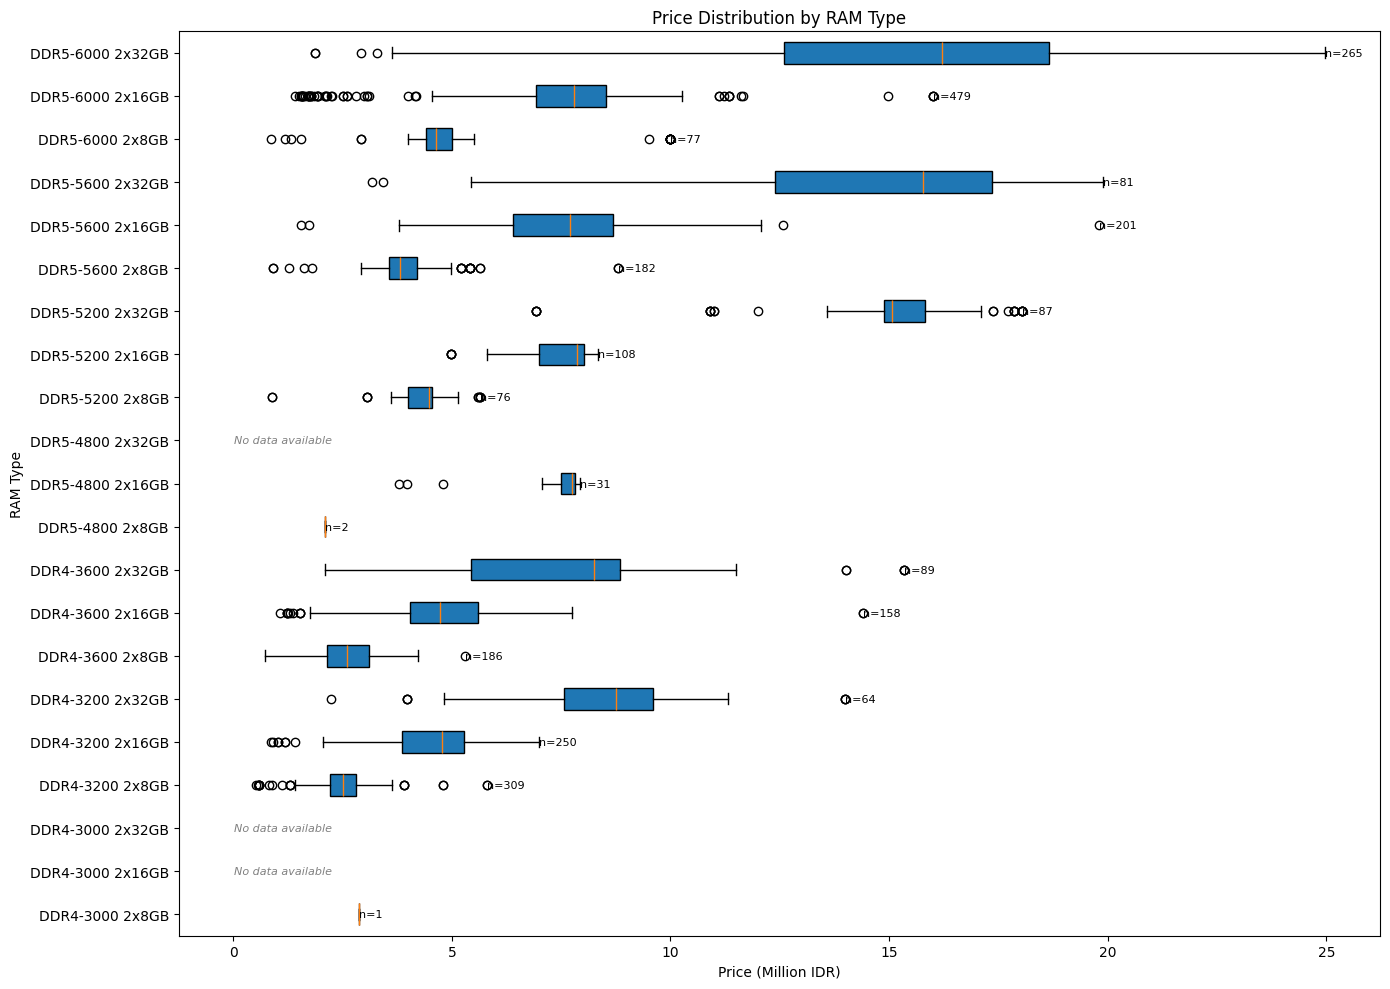

In [61]:
from price.shared import ProductCategory, ProductInfo, result_to_product_info
import re

prods = load_all_data(date.today())[ProductCategory.RAM]
prodinfos = map(lambda x: result_to_product_info(x.title + " " + (x.detail or ""), ProductCategory.RAM, int(x.price)), prods)
infos: list[ProductInfo] = list(filter(lambda x: x is not None, prodinfos)) # type: ignore

print(prods)

from price.shared import RAMType as _RAMType

prices_by_type = get_prices_by_ram_type(infos)

def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t.value)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    total = count * size
    return (gen, speed, total)

all_types = sorted(_RAMType, key=ram_sort_key)
labels = [t.value for t in all_types]
box_data = [([p / 1e6 for p in prices_by_type[t]] if t in prices_by_type else []) for t in all_types]

print(labels, box_data)
fig, ax = plt.subplots(figsize=(14, 10))
bp = ax.boxplot([d if d else [0] for d in box_data], tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("RAM Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by RAM Type")

for i, t in enumerate(all_types):
    if t in prices_by_type:
        ax.annotate(
            f"n={len(prices_by_type[t])}",
            xy=(max(box_data[i]), i + 1),
            ha="left",
            va="center",
            fontsize=8,
        )
    else:
        for element in [bp['boxes'][i], bp['medians'][i], bp['whiskers'][2*i], bp['whiskers'][2*i+1], bp['caps'][2*i], bp['caps'][2*i+1]]:
            element.set_visible(False)
        ax.annotate(
            'No data available',
            xy=(0.01, i + 1),
            ha="left",
            va="center",
            fontsize=8,
            fontstyle='italic',
            color='gray',
        )

plt.tight_layout()
plt.show()

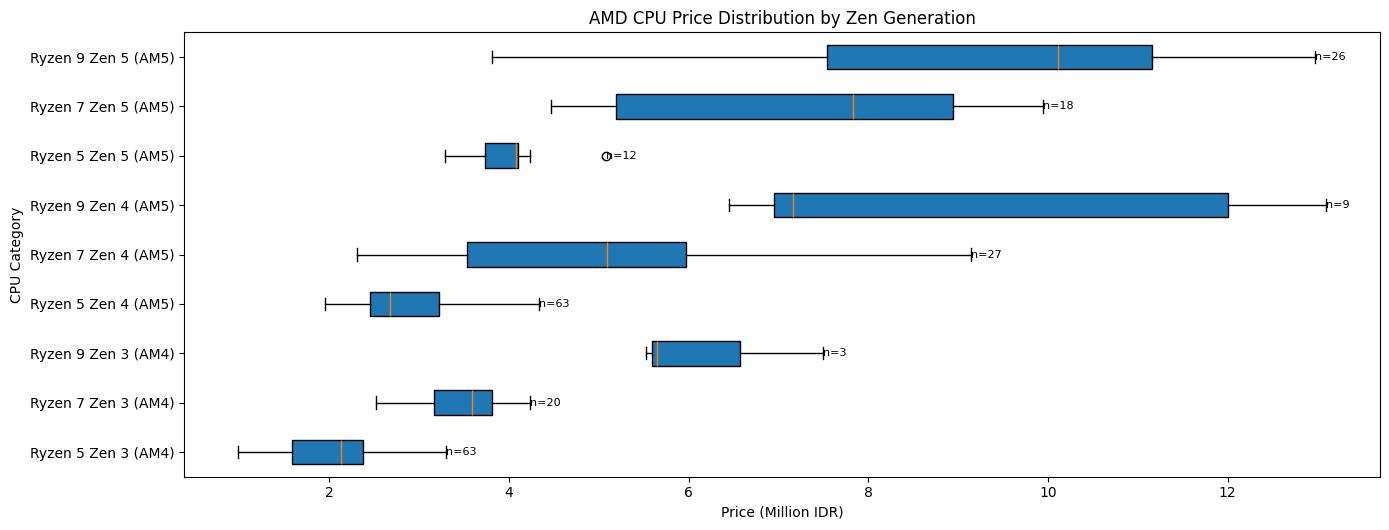

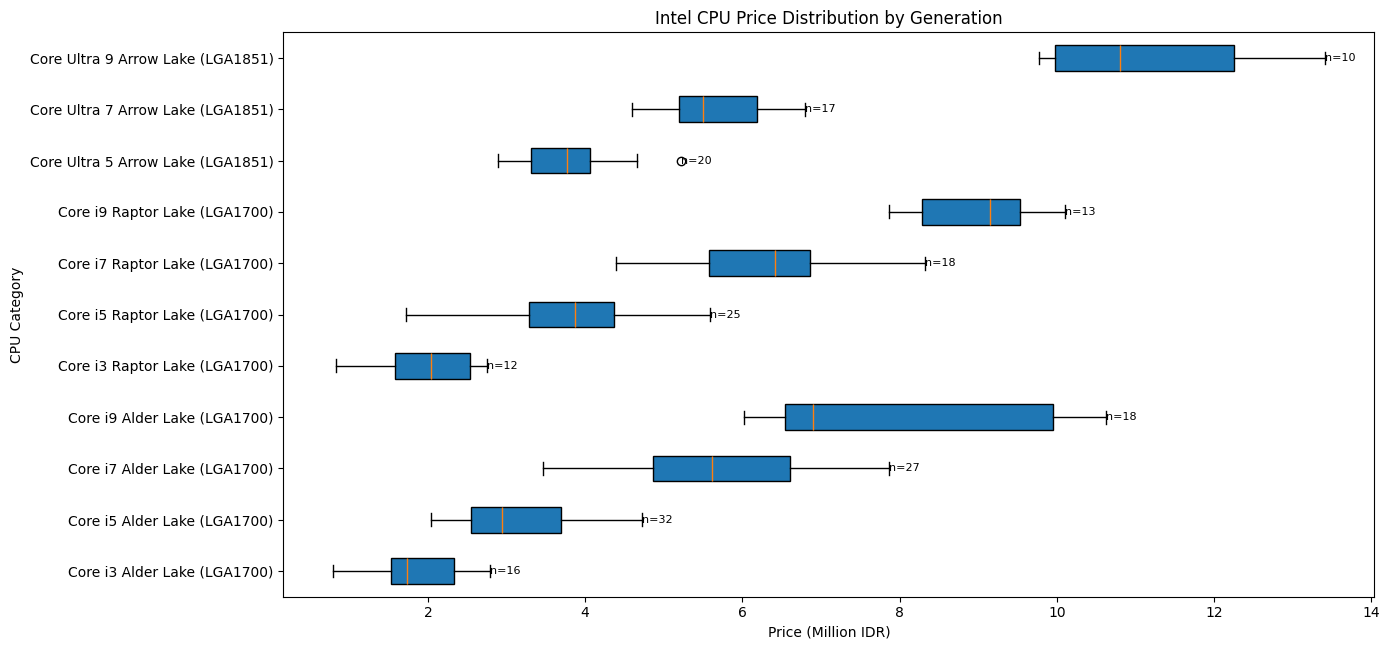

In [62]:
from collections import defaultdict
from price.shared import (
    ProductCategory, ProductInfo, result_to_product_info,
    CPUGeneration, CPUInfo, Brand
)
import re

prods = load_all_data(date.today())[ProductCategory.PROCESSOR]

def get_cpu_tier(title):
    if re.search(r'Core Ultra 9', title, re.IGNORECASE):
        return 'Core Ultra 9'
    if re.search(r'Core Ultra 7', title, re.IGNORECASE):
        return 'Core Ultra 7'
    if re.search(r'Core Ultra 5', title, re.IGNORECASE):
        return 'Core Ultra 5'
    if re.search(r'Ryzen 9', title, re.IGNORECASE):
        return 'Ryzen 9'
    if re.search(r'Ryzen 7', title, re.IGNORECASE):
        return 'Ryzen 7'
    if re.search(r'Ryzen 5', title, re.IGNORECASE):
        return 'Ryzen 5'
    if re.search(r'i9[- ]', title) or re.search(r'Core i9', title, re.IGNORECASE):
        return 'Core i9'
    if re.search(r'i7[- ]', title) or re.search(r'Core i7', title, re.IGNORECASE):
        return 'Core i7'
    if re.search(r'i5[- ]', title) or re.search(r'Core i5', title, re.IGNORECASE):
        return 'Core i5'
    if re.search(r'i3[- ]', title) or re.search(r'Core i3', title, re.IGNORECASE):
        return 'Core i3'
    return None

GEN_LABELS = {
    CPUGeneration.AMD_AM4: "Zen 3 (AM4)",
    CPUGeneration.AMD_AM5_Zen4: "Zen 4 (AM5)",
    CPUGeneration.AMD_AM5_Zen5: "Zen 5 (AM5)",
    CPUGeneration.Intel_LGA1700_AlderLake: "Alder Lake (LGA1700)",
    CPUGeneration.Intel_LGA1700_RaptorLake: "Raptor Lake (LGA1700)",
    CPUGeneration.Intel_LGA1851: "Arrow Lake (LGA1851)",
}

AMD_CPU_CATEGORIES = [
    "Ryzen 5 Zen 3 (AM4)",
    "Ryzen 7 Zen 3 (AM4)",
    "Ryzen 9 Zen 3 (AM4)",
    "Ryzen 5 Zen 4 (AM5)",
    "Ryzen 7 Zen 4 (AM5)",
    "Ryzen 9 Zen 4 (AM5)",
    "Ryzen 5 Zen 5 (AM5)",
    "Ryzen 7 Zen 5 (AM5)",
    "Ryzen 9 Zen 5 (AM5)",
]

INTEL_CPU_CATEGORIES = [
    "Core i3 Alder Lake (LGA1700)",
    "Core i5 Alder Lake (LGA1700)",
    "Core i7 Alder Lake (LGA1700)",
    "Core i9 Alder Lake (LGA1700)",
    "Core i3 Raptor Lake (LGA1700)",
    "Core i5 Raptor Lake (LGA1700)",
    "Core i7 Raptor Lake (LGA1700)",
    "Core i9 Raptor Lake (LGA1700)",
    "Core Ultra 5 Arrow Lake (LGA1851)",
    "Core Ultra 7 Arrow Lake (LGA1851)",
    "Core Ultra 9 Arrow Lake (LGA1851)",
]

ALL_CPU_CATEGORIES = AMD_CPU_CATEGORIES + INTEL_CPU_CATEGORIES

prices_by_cpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PROCESSOR, int(x.price))
    if info is None or not isinstance(info.details, CPUInfo):
        continue
    tier = get_cpu_tier(title)
    if tier is None:
        continue
    gen_label = GEN_LABELS.get(info.details.generation, "")
    label = f"{tier} {gen_label}"
    if label in ALL_CPU_CATEGORIES:
        prices_by_cpu[label].append(info.price)

def _plot_cpu_boxplot(categories, title):
    labels = categories
    box_data = [[p / 1e6 for p in prices_by_cpu[c]] if c in prices_by_cpu else [] for c in labels]
    fig, ax = plt.subplots(figsize=(14, max(5, len(labels) * 0.6)))
    bp = ax.boxplot([d if d else [0] for d in box_data], tick_labels=labels, vert=False, patch_artist=True)
    ax.set_ylabel("CPU Category")
    ax.set_xlabel("Price (Million IDR)")
    ax.set_title(title)
    for i, c in enumerate(labels):
        if c in prices_by_cpu:
            ax.annotate(
                f"n={len(prices_by_cpu[c])}",
                xy=(max(box_data[i]), i + 1),
                ha="left",
                va="center",
                fontsize=8,
            )
        else:
            for element in [bp['boxes'][i], bp['medians'][i], bp['whiskers'][2*i], bp['whiskers'][2*i+1], bp['caps'][2*i], bp['caps'][2*i+1]]:
                element.set_visible(False)
            ax.annotate(
                'No data available',
                xy=(0.01, i + 1),
                ha="left",
                va="center",
                fontsize=8,
                fontstyle='italic',
                color='gray',
            )
    plt.tight_layout()
    plt.show()

_plot_cpu_boxplot(AMD_CPU_CATEGORIES, 'AMD CPU Price Distribution by Zen Generation')
_plot_cpu_boxplot(INTEL_CPU_CATEGORIES, 'Intel CPU Price Distribution by Generation')

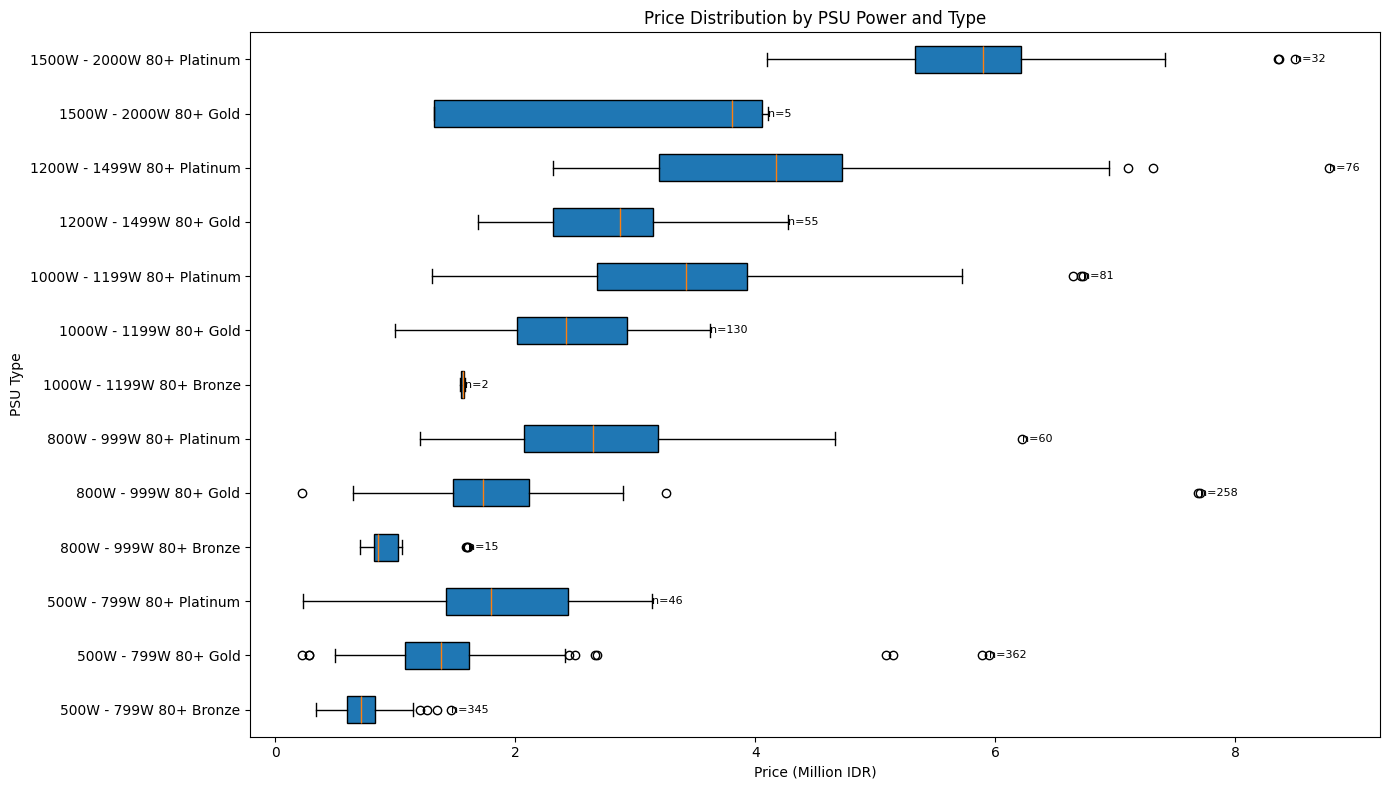

In [63]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, PSUInfo, PSUType, PSUPower
)

prods = load_all_data(date.today())[ProductCategory.PSU]

PSU_CATEGORIES = [
    "500W - 799W 80+ Bronze",
    "500W - 799W 80+ Gold",
    "500W - 799W 80+ Platinum",
    "800W - 999W 80+ Bronze",
    "800W - 999W 80+ Gold",
    "800W - 999W 80+ Platinum",
    "1000W - 1199W 80+ Bronze",
    "1000W - 1199W 80+ Gold",
    "1000W - 1199W 80+ Platinum",
    "1200W - 1499W 80+ Gold",
    "1200W - 1499W 80+ Platinum",
    "1500W - 2000W 80+ Gold",
    "1500W - 2000W 80+ Platinum",
]

prices_by_psu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PSU, int(x.price))
    if info is None or not isinstance(info.details, PSUInfo):
        continue
    try:
        power_range = info.details.power_range
    except ValueError:
        continue
    label = f"{power_range.value} 80+ {info.details.psu_type.value}"
    if label in PSU_CATEGORIES:
        prices_by_psu[label].append(info.price)

labels = PSU_CATEGORIES
box_data = [[p / 1e6 for p in prices_by_psu[c]] if c in prices_by_psu else [] for c in labels]

fig, ax = plt.subplots(figsize=(14, 8))
bp = ax.boxplot([d if d else [0] for d in box_data], tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("PSU Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by PSU Power and Type")

for i, c in enumerate(labels):
    if c in prices_by_psu:
        ax.annotate(
            f"n={len(prices_by_psu[c])}",
            xy=(max(box_data[i]), i + 1),
            ha="left",
            va="center",
            fontsize=8,
        )
    else:
        for element in [bp['boxes'][i], bp['medians'][i], bp['whiskers'][2*i], bp['whiskers'][2*i+1], bp['caps'][2*i], bp['caps'][2*i+1]]:
            element.set_visible(False)
        ax.annotate(
            'No data available',
            xy=(0.01, i + 1),
            ha="left",
            va="center",
            fontsize=8,
            fontstyle='italic',
            color='gray',
        )

plt.tight_layout()
plt.show()

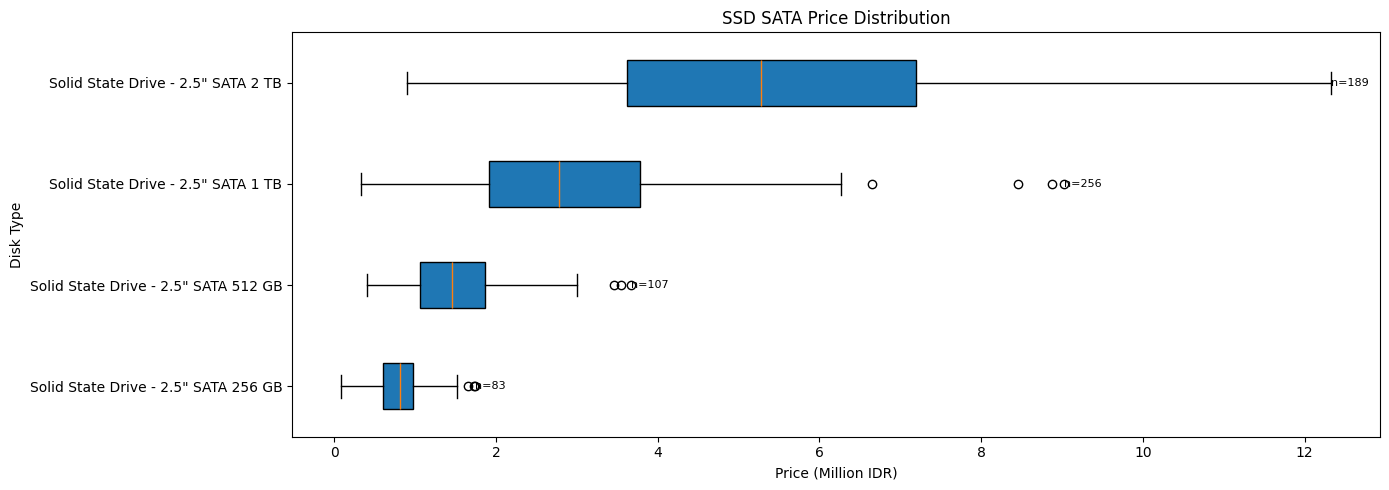

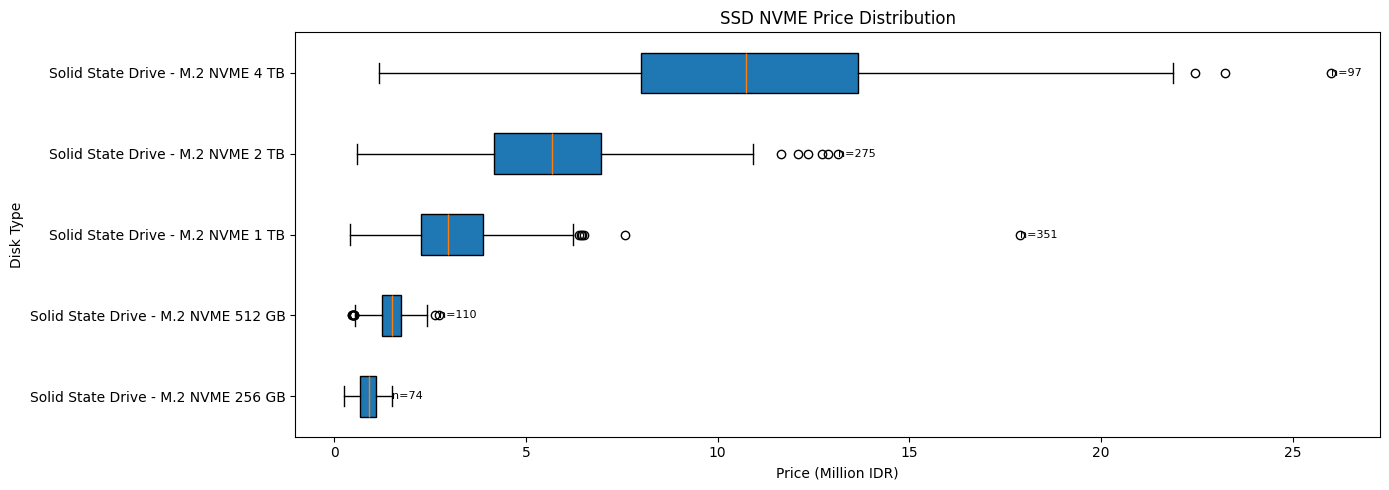

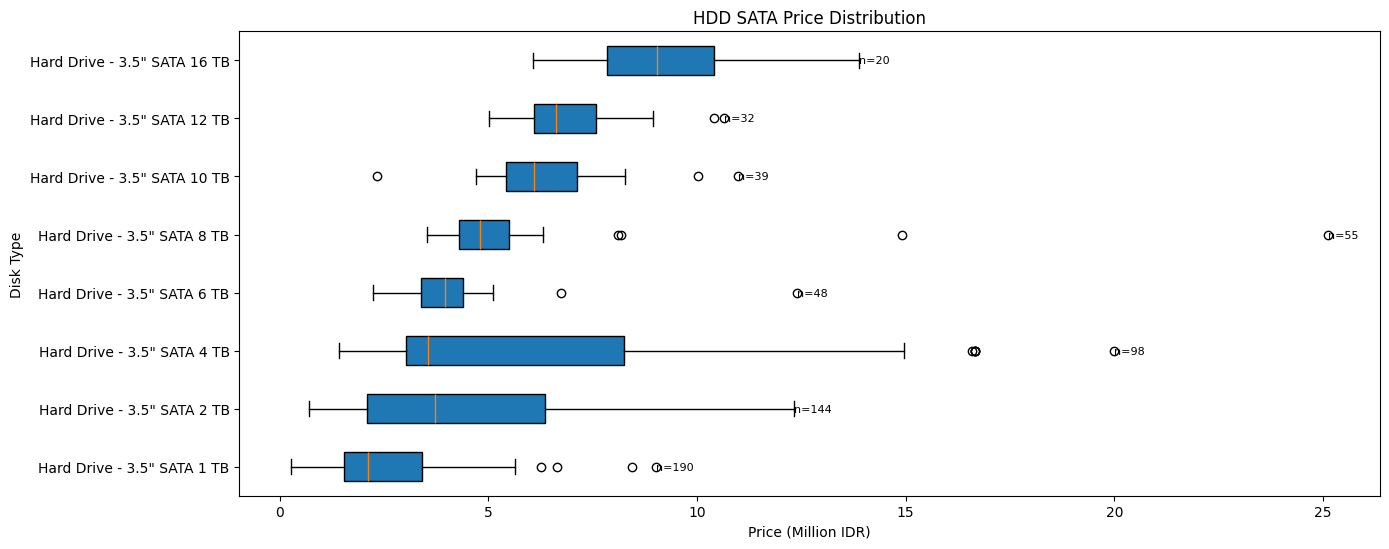

In [64]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, DiskInfo, DiskType, FormFactor
)

ssd_prods = load_all_data(date.today())[ProductCategory.SSD]
hdd_prods = load_all_data(date.today())[ProductCategory.HARDDISK]

def format_capacity(capacity_gb):
    if capacity_gb >= 1000:
        return f"{capacity_gb // 1000} TB"
    return f"{capacity_gb} GB"

DISK_TYPE_LABELS = {
    DiskType.SSD: "Solid State Drive",
    DiskType.HDD: "Hard Drive",
}

SSD_SATA_CATEGORIES = [
    'Solid State Drive - 2.5" SATA 256 GB',
    'Solid State Drive - 2.5" SATA 512 GB',
    'Solid State Drive - 2.5" SATA 1 TB',
    'Solid State Drive - 2.5" SATA 2 TB',
]

SSD_NVME_CATEGORIES = [
    "Solid State Drive - M.2 NVME 256 GB",
    "Solid State Drive - M.2 NVME 512 GB",
    "Solid State Drive - M.2 NVME 1 TB",
    "Solid State Drive - M.2 NVME 2 TB",
    "Solid State Drive - M.2 NVME 4 TB",
]

HDD_SATA_CATEGORIES = [
    'Hard Drive - 3.5" SATA 1 TB',
    'Hard Drive - 3.5" SATA 2 TB',
    'Hard Drive - 3.5" SATA 4 TB',
    'Hard Drive - 3.5" SATA 6 TB',
    'Hard Drive - 3.5" SATA 8 TB',
    'Hard Drive - 3.5" SATA 10 TB',
    'Hard Drive - 3.5" SATA 12 TB',
    'Hard Drive - 3.5" SATA 16 TB',
]

ALL_DISK_CATEGORIES = SSD_SATA_CATEGORIES + SSD_NVME_CATEGORIES + HDD_SATA_CATEGORIES

prices_by_disk = defaultdict(list)
for cat, prods in [(ProductCategory.SSD, ssd_prods), (ProductCategory.HARDDISK, hdd_prods)]:
    for x in prods:
        title = x.title + " " + (x.detail or "")
        info = result_to_product_info(title, cat, int(x.price))
        if info is None or not isinstance(info.details, DiskInfo):
            continue
        d = info.details
        type_label = DISK_TYPE_LABELS[d.disk_type]
        label = f"{type_label} - {d.form_factor.value} {format_capacity(d.capacity_gb)}"
        if label in ALL_DISK_CATEGORIES:
            prices_by_disk[label].append(info.price)

def _plot_disk_boxplot(categories, title):
    labels = categories
    box_data = [[p / 1e6 for p in prices_by_disk[c]] if c in prices_by_disk else [] for c in labels]
    fig, ax = plt.subplots(figsize=(14, max(5, len(labels) * 0.7)))
    bp = ax.boxplot([d if d else [0] for d in box_data], tick_labels=labels, vert=False, patch_artist=True)
    ax.set_ylabel("Disk Type")
    ax.set_xlabel("Price (Million IDR)")
    ax.set_title(title)
    for i, c in enumerate(labels):
        if c in prices_by_disk:
            ax.annotate(
                f"n={len(prices_by_disk[c])}",
                xy=(max(box_data[i]), i + 1),
                ha="left",
                va="center",
                fontsize=8,
            )
        else:
            for element in [bp['boxes'][i], bp['medians'][i], bp['whiskers'][2*i], bp['whiskers'][2*i+1], bp['caps'][2*i], bp['caps'][2*i+1]]:
                element.set_visible(False)
            ax.annotate(
                'No data available',
                xy=(0.01, i + 1),
                ha="left",
                va="center",
                fontsize=8,
                fontstyle='italic',
                color='gray',
            )
    plt.tight_layout()
    plt.show()

_plot_disk_boxplot(SSD_SATA_CATEGORIES, 'SSD SATA Price Distribution')
_plot_disk_boxplot(SSD_NVME_CATEGORIES, 'SSD NVME Price Distribution')
_plot_disk_boxplot(HDD_SATA_CATEGORIES, 'HDD SATA Price Distribution')

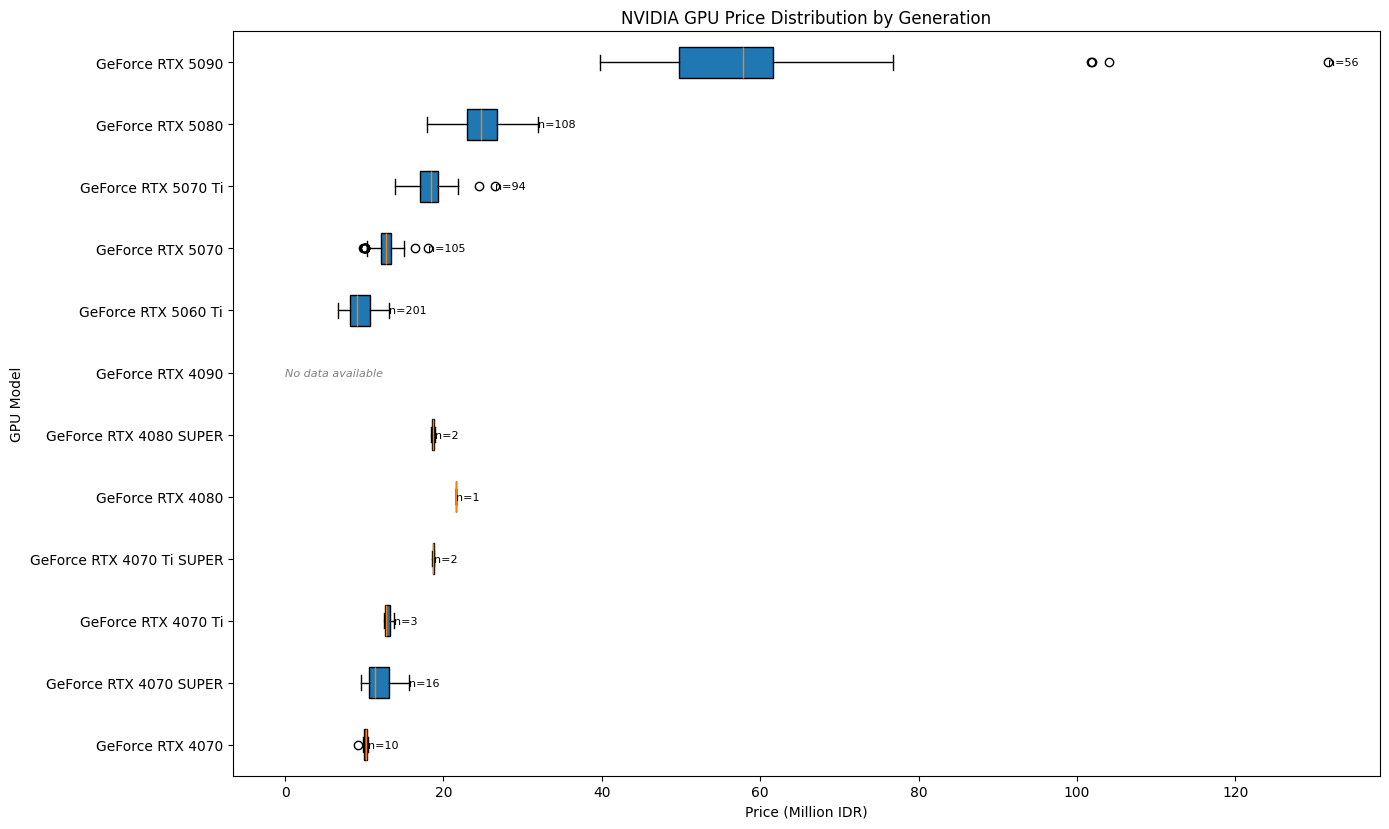

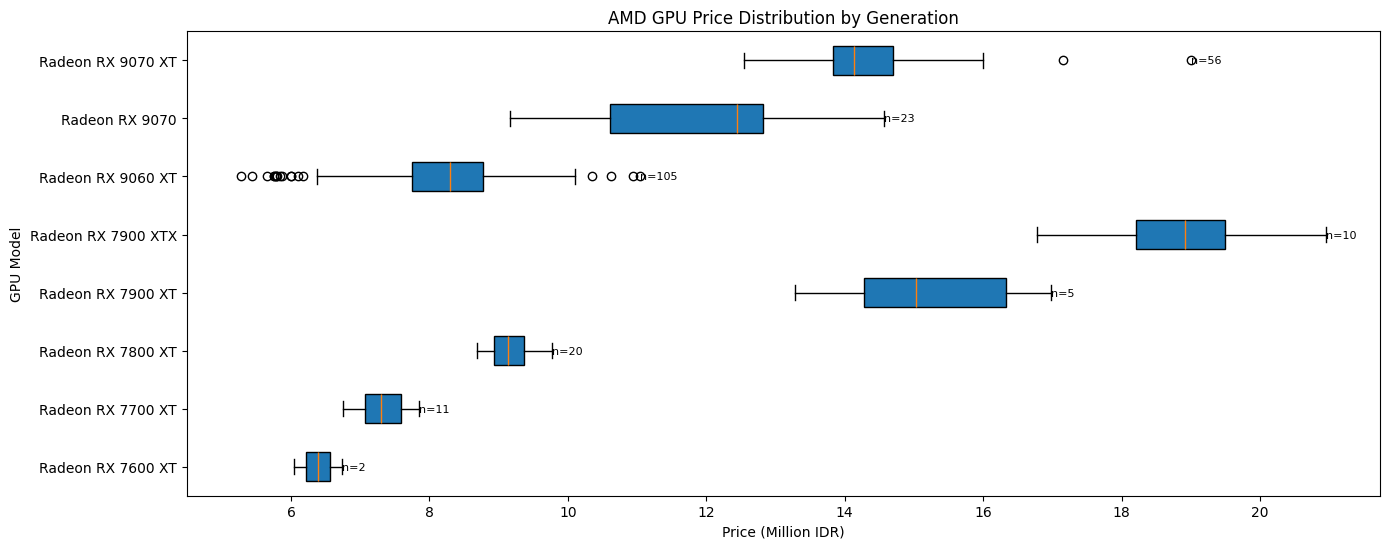

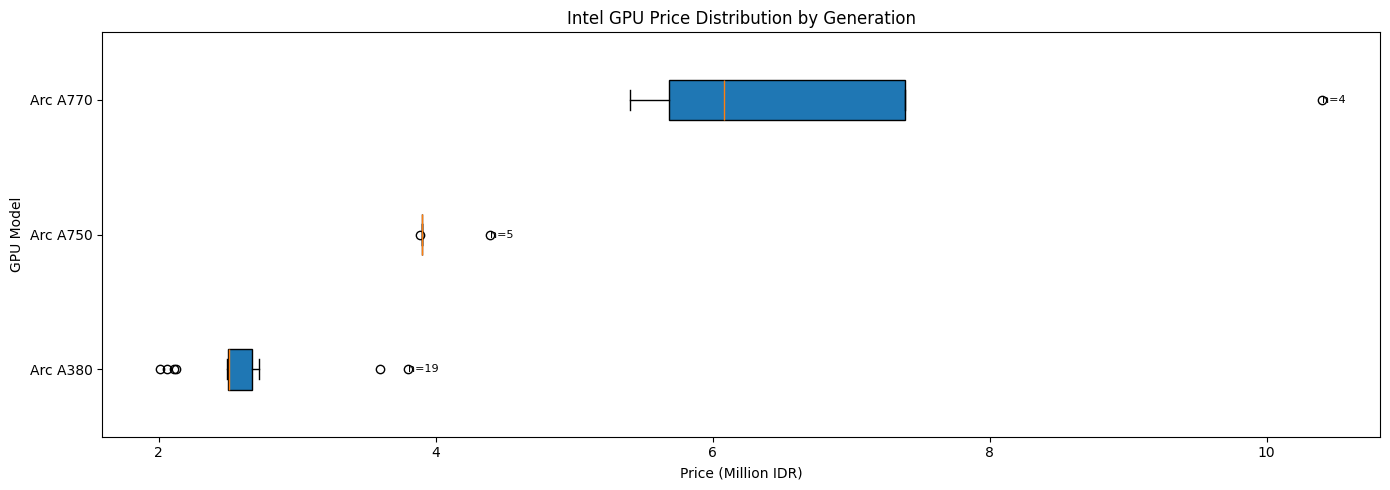

In [65]:
from collections import defaultdict
from price.shared import ProductCategory
import re

prods = load_all_data(date.today())[ProductCategory.VGA]

GPU_MODELS = [
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 7900 XT",
    "Radeon RX 9060 XT",
    "Radeon RX 9070 XT",
    "Radeon RX 9070",
    "Arc A770",
    "Arc A750",
    "Arc A380",
]

NVIDIA_GPU_ORDER = [
    "GeForce RTX 4070",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
]

AMD_GPU_ORDER = [
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 9060 XT",
    "Radeon RX 9070",
    "Radeon RX 9070 XT",
]

INTEL_GPU_ORDER = [
    "Arc A380",
    "Arc A750",
    "Arc A770",
]

def get_gpu_category(title):
    title_lower = title.lower()
    for model in GPU_MODELS:
        if model.lower() in title_lower:
            return model
    return None

prices_by_gpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    model = get_gpu_category(title)
    if model is None:
        continue
    prices_by_gpu[model].append(int(x.price))

def _plot_gpu_boxplot(categories, title):
    labels = categories
    box_data = [[p / 1e6 for p in prices_by_gpu[c]] if c in prices_by_gpu else [] for c in labels]
    fig, ax = plt.subplots(figsize=(14, max(5, len(labels) * 0.7)))
    bp = ax.boxplot([d if d else [0] for d in box_data], tick_labels=labels, vert=False, patch_artist=True)
    ax.set_ylabel("GPU Model")
    ax.set_xlabel("Price (Million IDR)")
    ax.set_title(title)
    for i, c in enumerate(labels):
        if c in prices_by_gpu:
            ax.annotate(
                f"n={len(prices_by_gpu[c])}",
                xy=(max(box_data[i]), i + 1),
                ha="left",
                va="center",
                fontsize=8,
            )
        else:
            for element in [bp['boxes'][i], bp['medians'][i], bp['whiskers'][2*i], bp['whiskers'][2*i+1], bp['caps'][2*i], bp['caps'][2*i+1]]:
                element.set_visible(False)
            ax.annotate(
                'No data available',
                xy=(0.01, i + 1),
                ha="left",
                va="center",
                fontsize=8,
                fontstyle='italic',
                color='gray',
            )
    plt.tight_layout()
    plt.show()

_plot_gpu_boxplot(NVIDIA_GPU_ORDER, 'NVIDIA GPU Price Distribution by Generation')
_plot_gpu_boxplot(AMD_GPU_ORDER, 'AMD GPU Price Distribution by Generation')
_plot_gpu_boxplot(INTEL_GPU_ORDER, 'Intel GPU Price Distribution by Generation')

In [66]:
from pathlib import Path
from datetime import date
from statistics import median, quantiles
from collections import defaultdict
from price.data import load_all_data
from price.shared import (
    ProductCategory, ProductInfo, result_to_product_info,
    CPUGeneration, CPUInfo, Brand,
    PSUInfo, PSUType, PSUPower,
    DiskInfo, DiskType, FormFactor,
    RAMType, RAMInfo,
)
from price.source.generic import GenericData
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

# Discover all date directories and sort them
data_dir = Path("data")
date_dirs = sorted(d.name for d in data_dir.iterdir() if d.is_dir())
dates = [date.fromisoformat(d) for d in date_dirs]

# Pre-load all data for each date
all_data_by_date = {}
for dt in dates:
    all_data_by_date[dt] = load_all_data(dt)

print(dates)

def plot_historical_trend(dates, medians_by_subcategory, q1_by_subcategory, q3_by_subcategory, subcategory_order, title, ylabel, show_all=False, max_cols=3, collect_figs=None):
    if show_all:
        active_labels = list(subcategory_order)
    else:
        active_labels = [l for l in subcategory_order if l in medians_by_subcategory and any(v is not None for v in medians_by_subcategory[l])]
    if not active_labels:
        return
    n = len(active_labels)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    fig.suptitle(title, fontsize=14)
    for idx, label in enumerate(active_labels):
        r, c = divmod(idx, cols)
        ax = axes[r][c]
        has_data = label in medians_by_subcategory and any(v is not None for v in medians_by_subcategory[label])
        if has_data:
            vals = medians_by_subcategory[label]
            q1_vals = q1_by_subcategory[label]
            q3_vals = q3_by_subcategory[label]
            plot_dates = [d for d, v in zip(dates, vals) if v is not None]
            plot_vals = [v for v in vals if v is not None]
            plot_q1 = [q for q, v in zip(q1_vals, vals) if v is not None]
            plot_q3 = [q for q, v in zip(q3_vals, vals) if v is not None]
            if plot_vals:
                ax.plot(plot_dates, plot_vals, marker='o', color='tab:blue')
                ax.fill_between(plot_dates, plot_q1, plot_q3, alpha=0.2, color='gray')
                all_vals = plot_vals + plot_q1 + plot_q3
                ymin, ymax = min(all_vals), max(all_vals)
                margin = max((ymax - ymin) * 0.3, ymax * 0.1)
                ax.set_ylim(max(0, ymin - margin), ymax + margin)
            ax.set_ylabel('Million IDR', fontsize=8)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
            ax.tick_params(axis='x', rotation=45, labelsize=7)
            ax.tick_params(axis='y', labelsize=7)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=10, transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        ax.set_title(label, fontsize=9)
    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r][c].set_visible(False)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if collect_figs is not None:
        collect_figs.append((title, fig))
        plt.close(fig)
    else:
        plt.show()

[datetime.date(2026, 2, 25), datetime.date(2026, 2, 27), datetime.date(2026, 3, 1), datetime.date(2026, 3, 2), datetime.date(2026, 3, 3)]


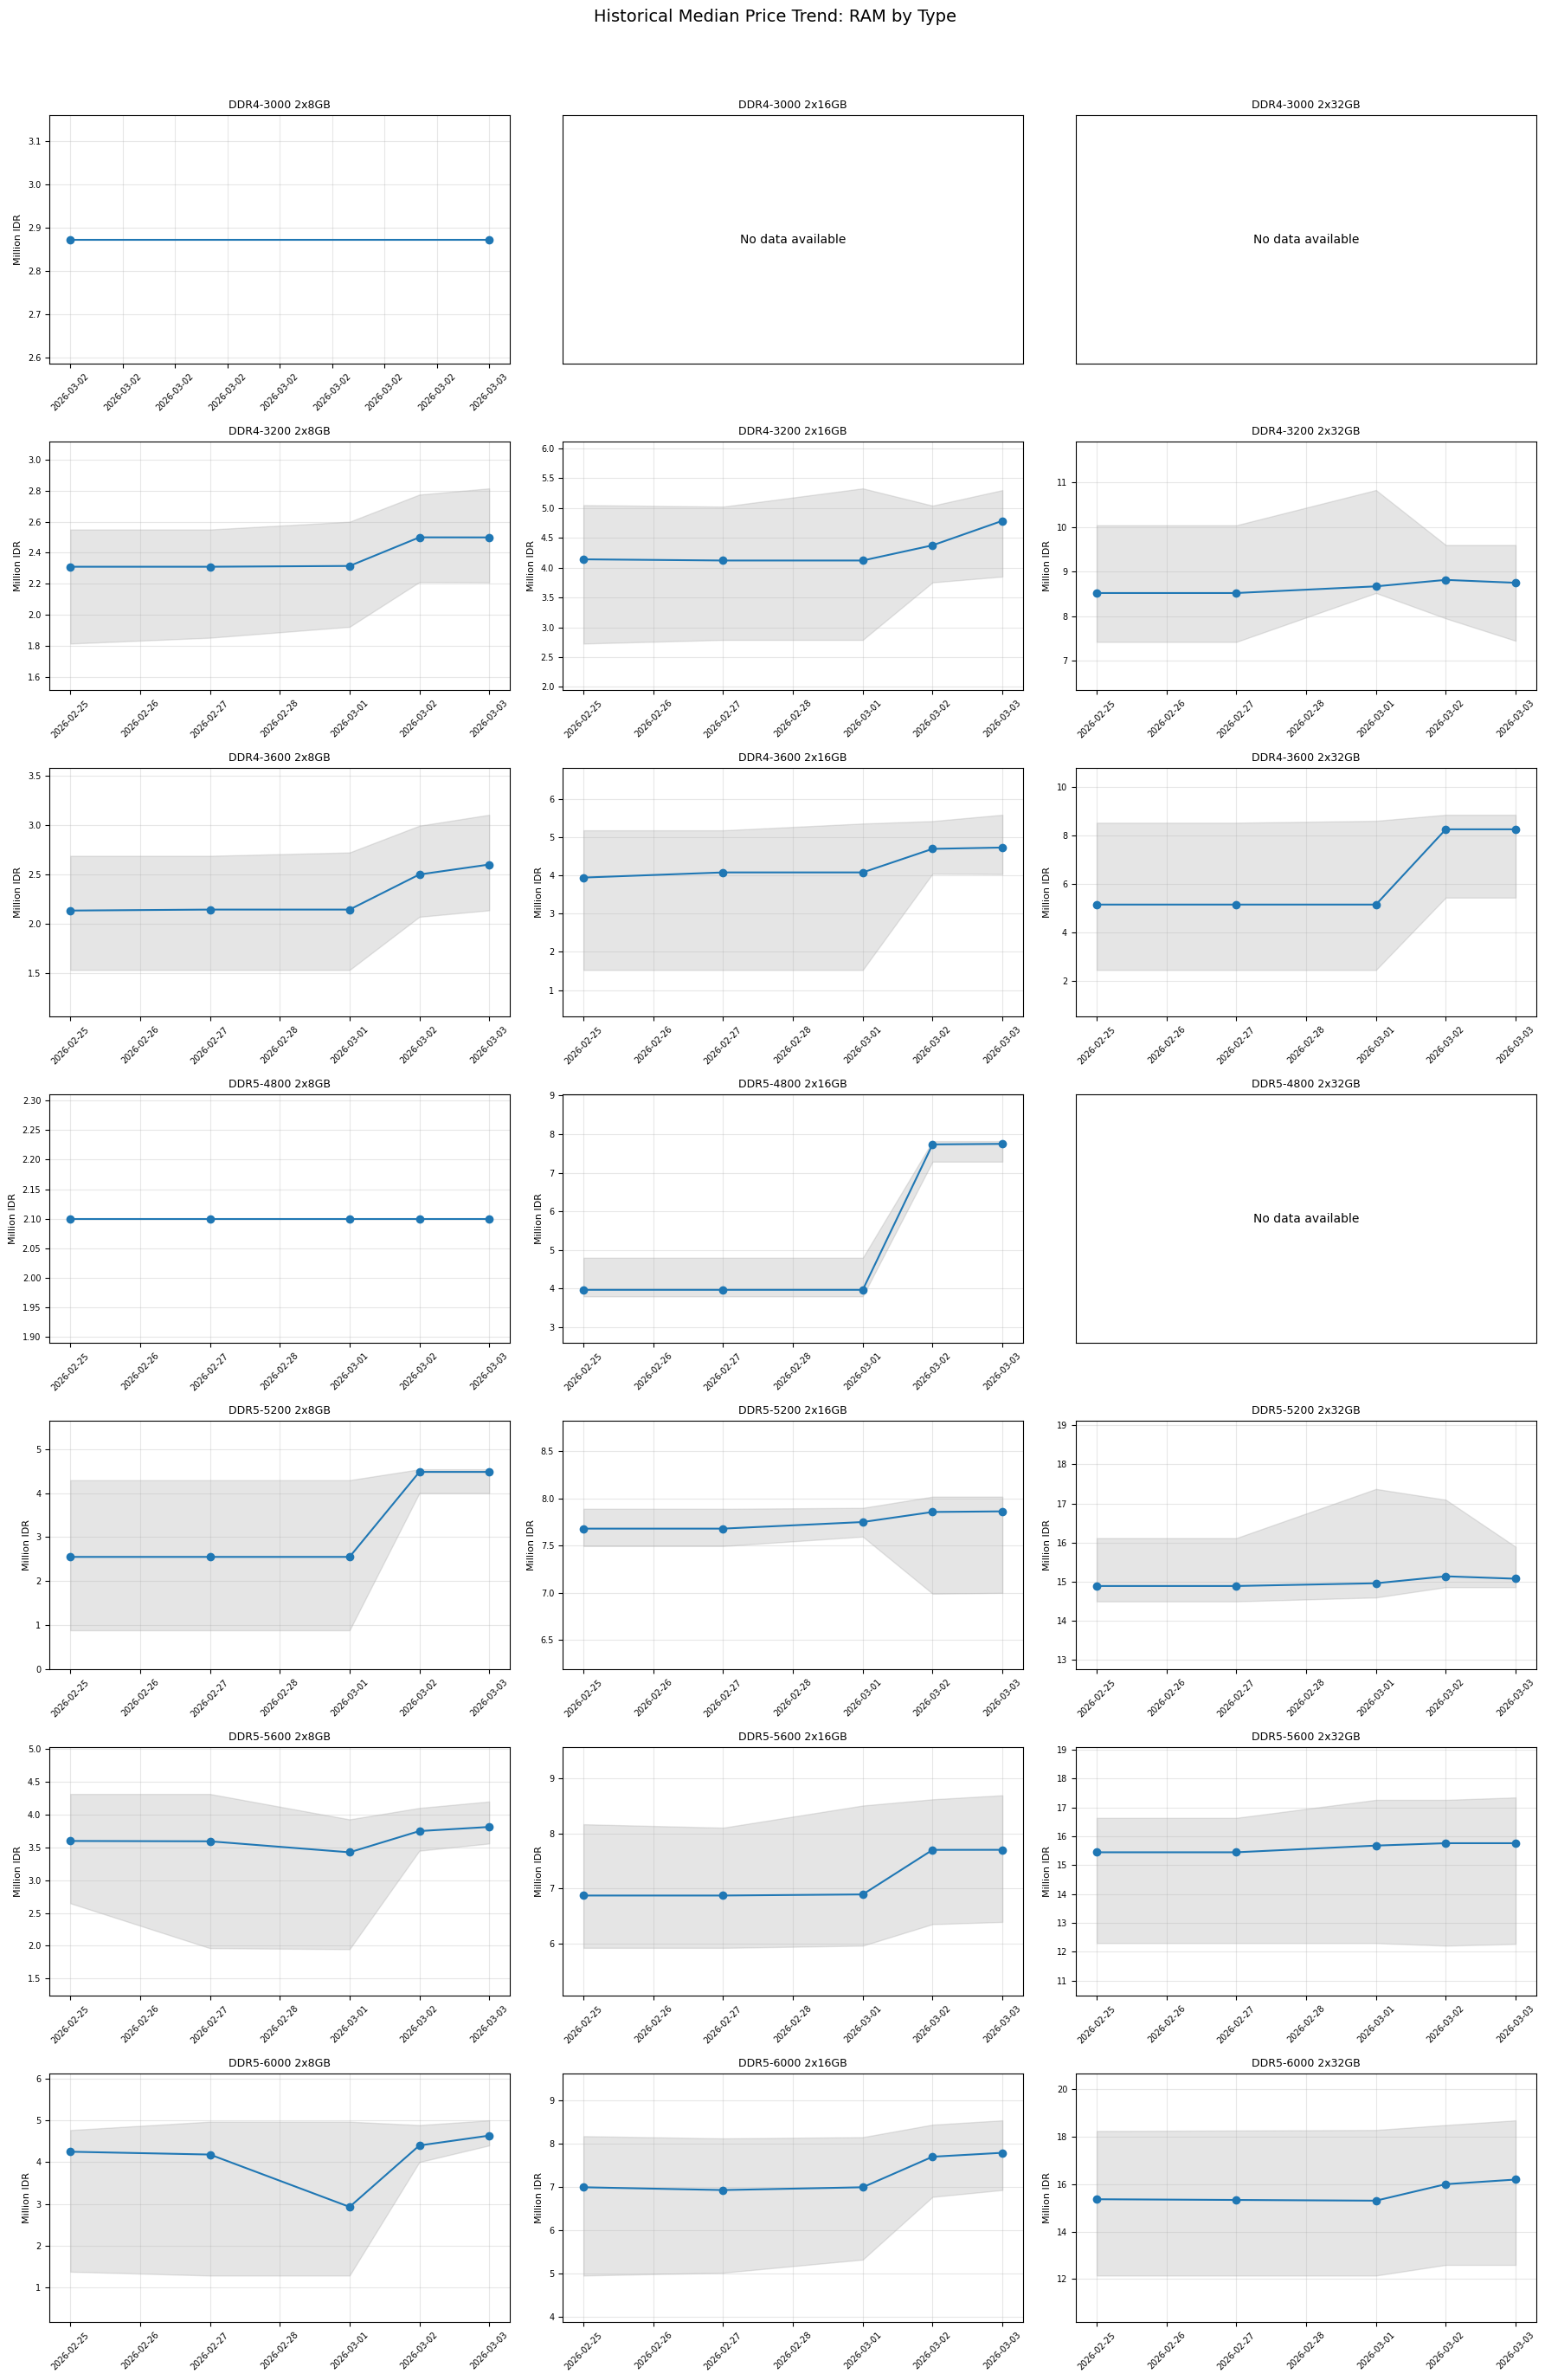

In [ ]:
# Historical trend: RAM by type (grouped by speed, one row per speed)
def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    return (gen, speed, count * size)

ALL_RAM_LABELS = sorted([rt.value for rt in RAMType], key=ram_sort_key)

ram_medians: dict[str, list[float | None]] = defaultdict(list)
ram_q1: dict[str, list[float | None]] = defaultdict(list)
ram_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.RAM, [])
    prodinfos = [result_to_product_info(x.title + ' ' + (x.detail or ''), ProductCategory.RAM, int(x.price)) for x in prods]
    infos = [x for x in prodinfos if x is not None and isinstance(x.details, RAMInfo)]
    prices_by_type: dict[str, list[int]] = defaultdict(list)
    for item in infos:
        prices_by_type[item.details.ram_type.value].append(item.price)
    for label in ALL_RAM_LABELS:
        if label in prices_by_type:
            prices = prices_by_type[label]
            ram_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                ram_q1[label].append(qs[0] / 1e6)
                ram_q3[label].append(qs[2] / 1e6)
            else:
                ram_q1[label].append(prices[0] / 1e6)
                ram_q3[label].append(prices[0] / 1e6)
        else:
            ram_medians[label].append(None)
            ram_q1[label].append(None)
            ram_q3[label].append(None)

plot_historical_trend(dates, ram_medians, ram_q1, ram_q3, ALL_RAM_LABELS,
    'RAM by Type', 'RAM Type', show_all=True)

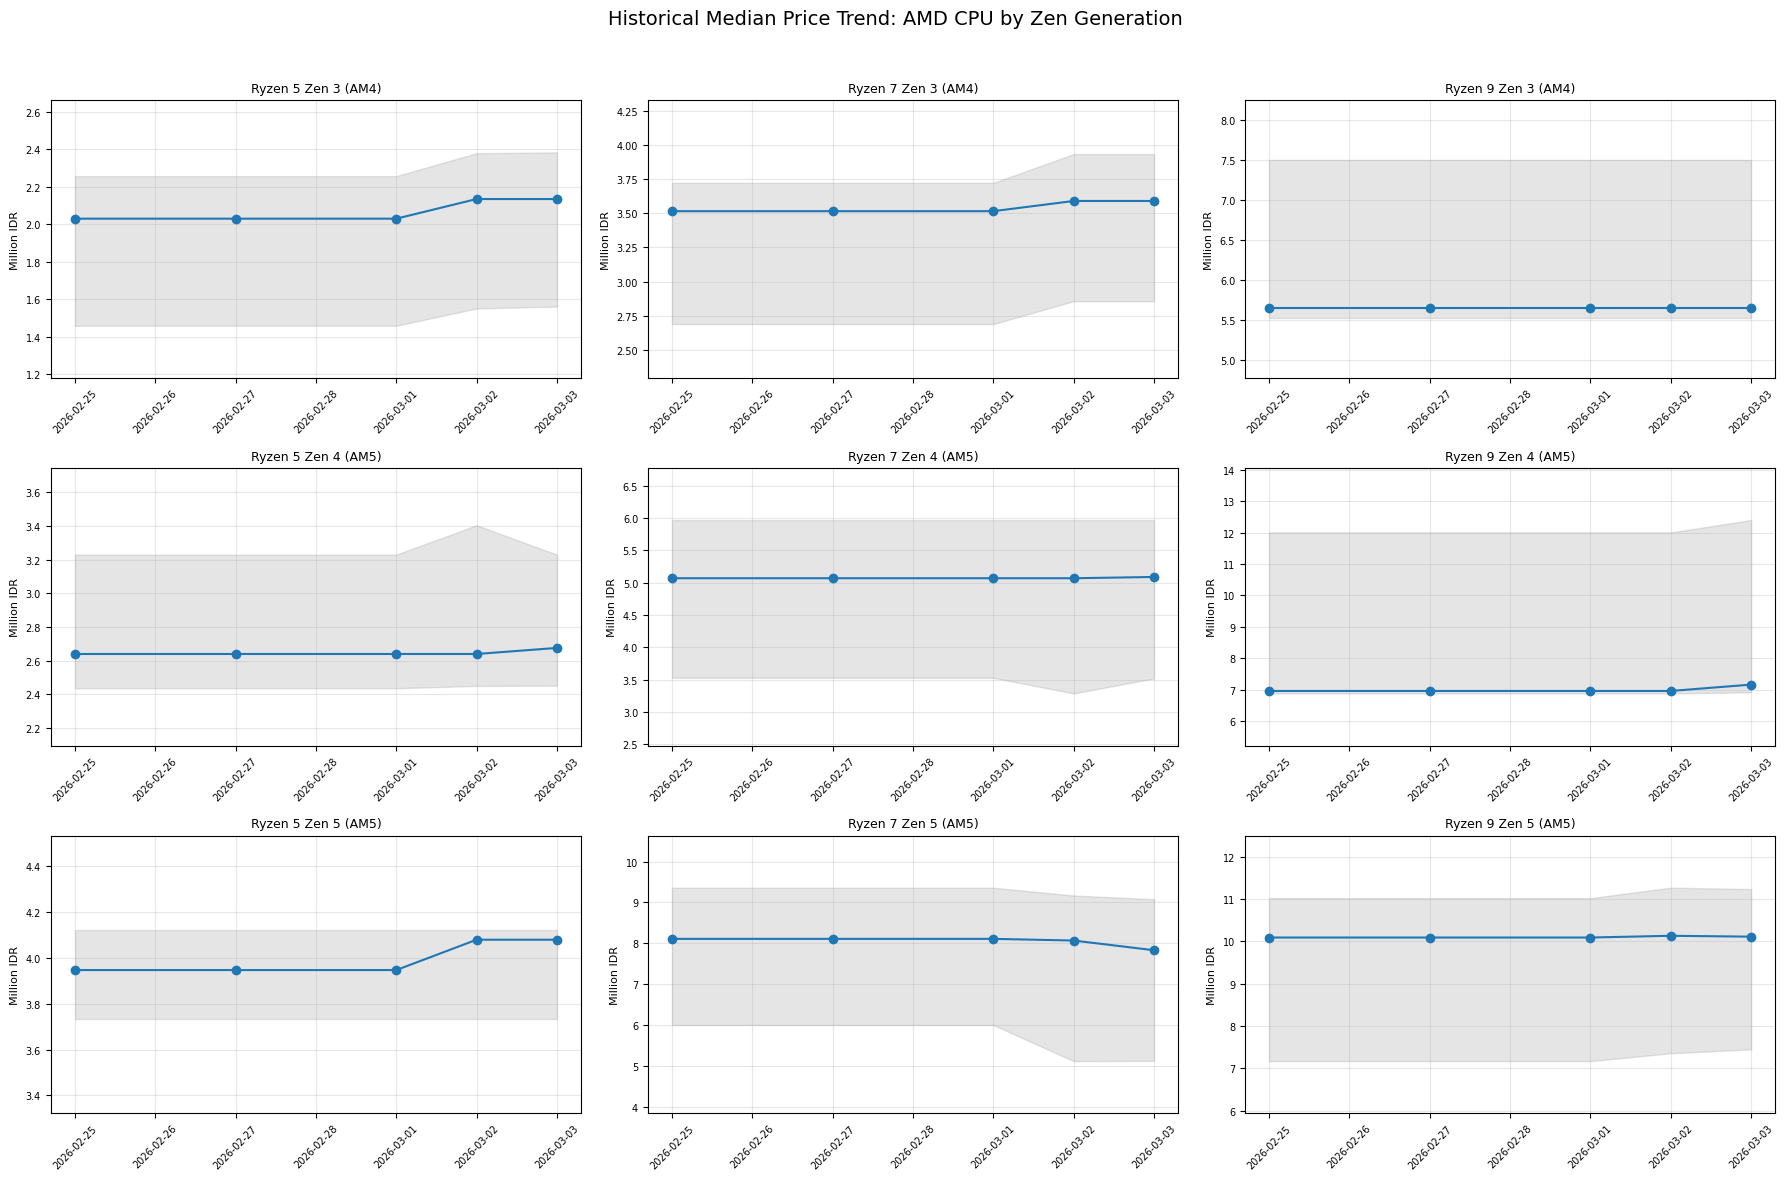

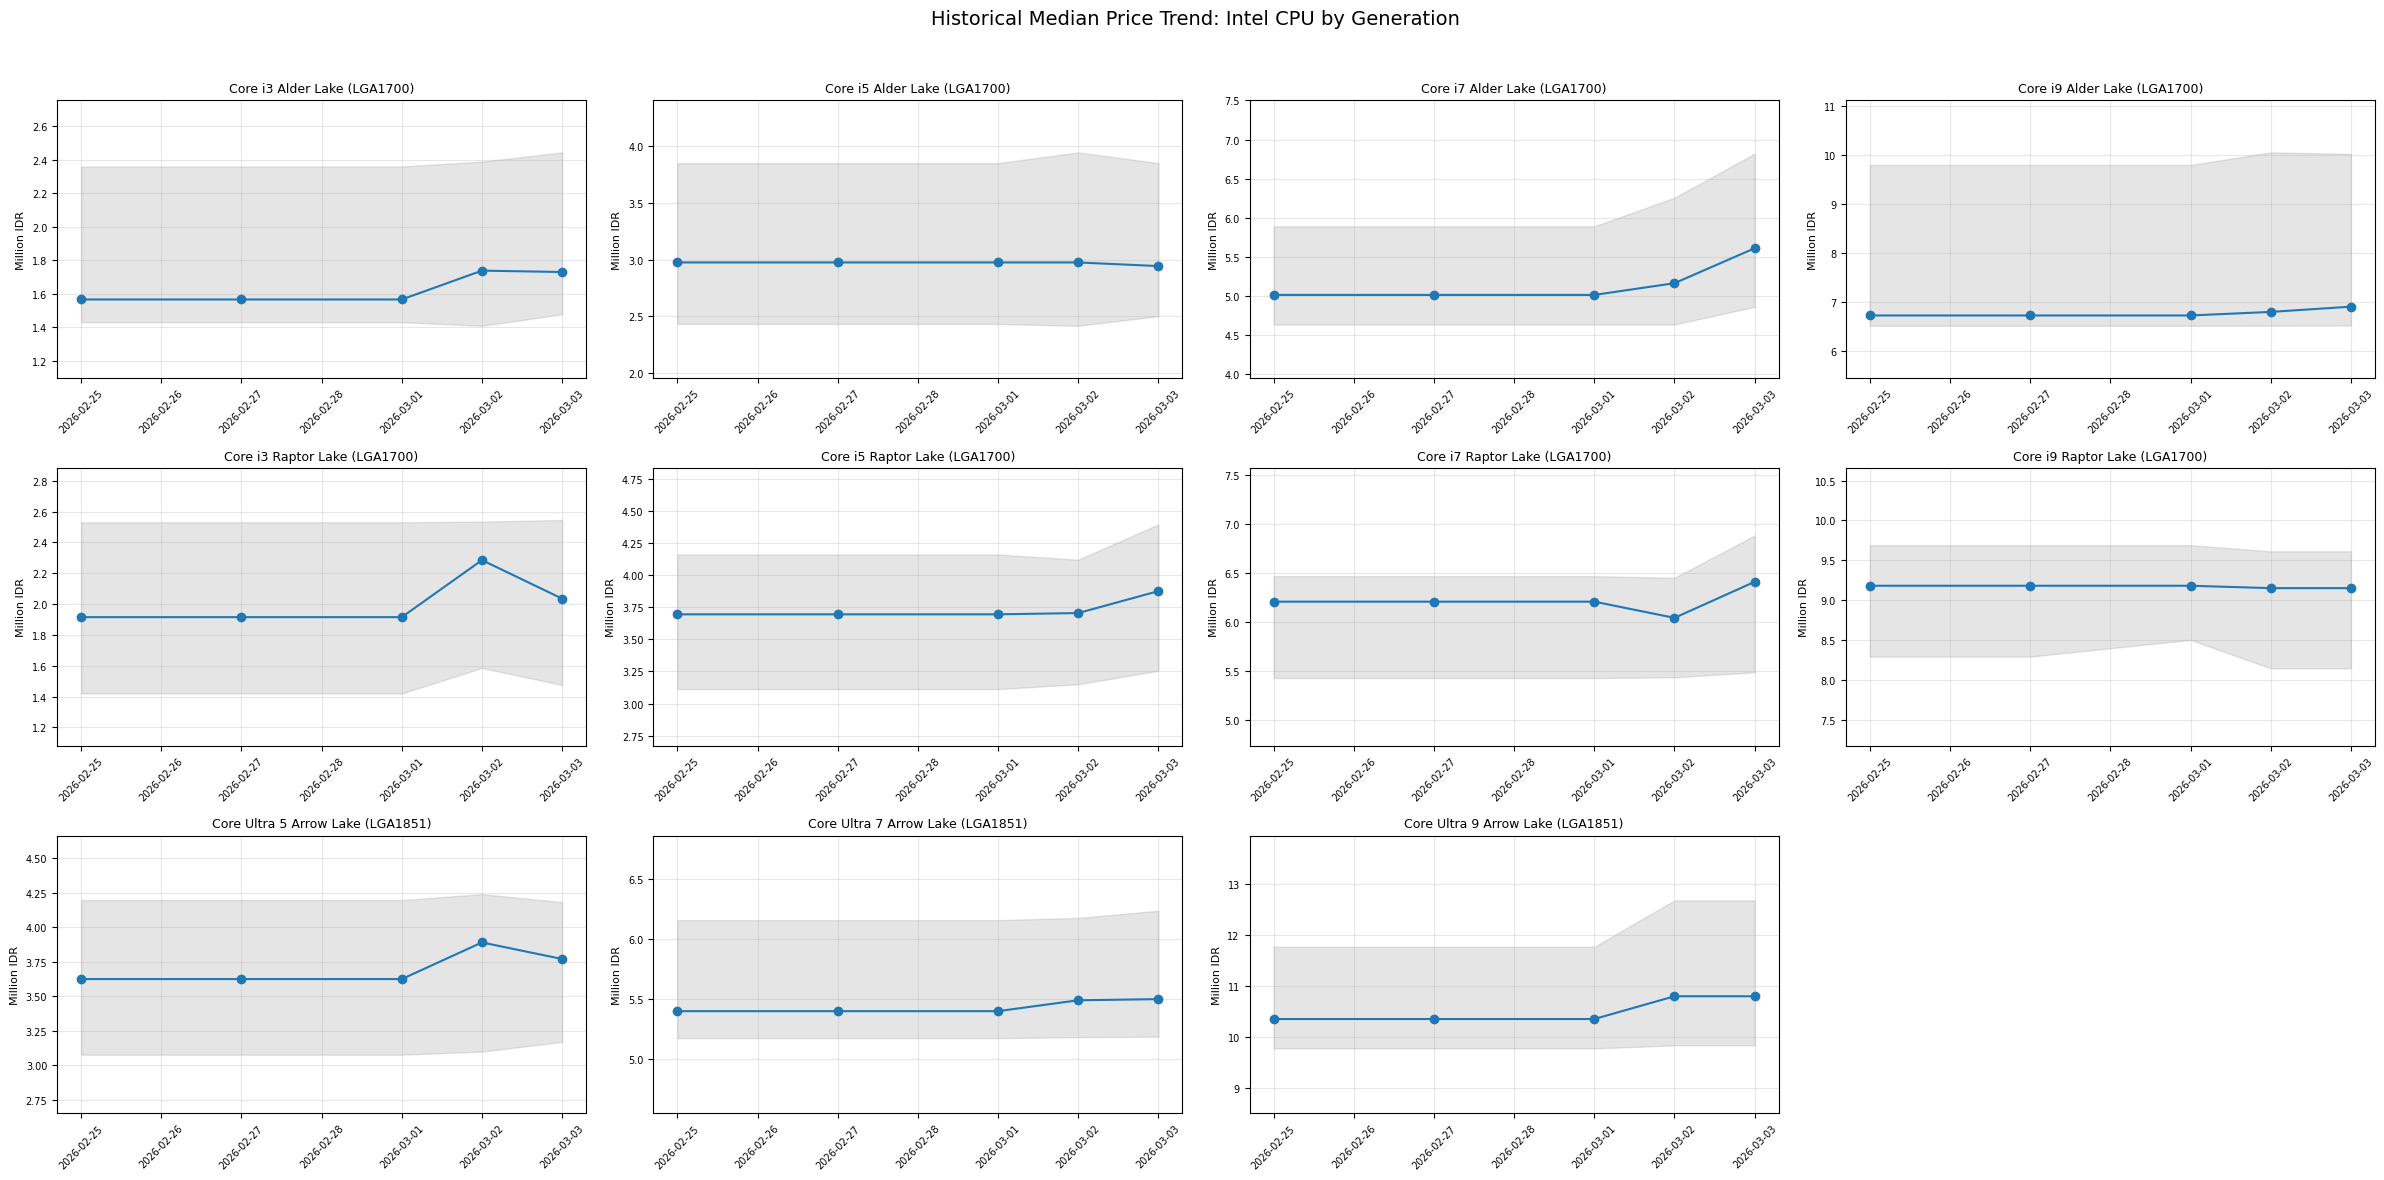

In [ ]:
# Historical trend: CPU by generation/tier — split AMD and Intel
def get_cpu_tier(title):
    for pattern, label in [
        (r'Core Ultra 9', 'Core Ultra 9'), (r'Core Ultra 7', 'Core Ultra 7'),
        (r'Core Ultra 5', 'Core Ultra 5'),
        (r'Ryzen 9', 'Ryzen 9'), (r'Ryzen 7', 'Ryzen 7'), (r'Ryzen 5', 'Ryzen 5'),
        (r'i9[- ]|Core i9', 'Core i9'), (r'i7[- ]|Core i7', 'Core i7'),
        (r'i5[- ]|Core i5', 'Core i5'), (r'i3[- ]|Core i3', 'Core i3'),
    ]:
        if re.search(pattern, title, re.IGNORECASE):
            return label
    return None

GEN_LABELS = {
    CPUGeneration.AMD_AM4: 'Zen 3 (AM4)',
    CPUGeneration.AMD_AM5_Zen4: 'Zen 4 (AM5)',
    CPUGeneration.AMD_AM5_Zen5: 'Zen 5 (AM5)',
    CPUGeneration.Intel_LGA1700_AlderLake: 'Alder Lake (LGA1700)',
    CPUGeneration.Intel_LGA1700_RaptorLake: 'Raptor Lake (LGA1700)',
    CPUGeneration.Intel_LGA1851: 'Arrow Lake (LGA1851)',
}

AMD_CPU_CATEGORIES = [
    'Ryzen 5 Zen 3 (AM4)', 'Ryzen 7 Zen 3 (AM4)', 'Ryzen 9 Zen 3 (AM4)',
    'Ryzen 5 Zen 4 (AM5)', 'Ryzen 7 Zen 4 (AM5)', 'Ryzen 9 Zen 4 (AM5)',
    'Ryzen 5 Zen 5 (AM5)', 'Ryzen 7 Zen 5 (AM5)', 'Ryzen 9 Zen 5 (AM5)',
]

INTEL_CPU_CATEGORIES = [
    'Core i3 Alder Lake (LGA1700)', 'Core i5 Alder Lake (LGA1700)',
    'Core i7 Alder Lake (LGA1700)', 'Core i9 Alder Lake (LGA1700)',
    'Core i3 Raptor Lake (LGA1700)', 'Core i5 Raptor Lake (LGA1700)',
    'Core i7 Raptor Lake (LGA1700)', 'Core i9 Raptor Lake (LGA1700)',
    'Core Ultra 5 Arrow Lake (LGA1851)', 'Core Ultra 7 Arrow Lake (LGA1851)',
    'Core Ultra 9 Arrow Lake (LGA1851)',
]

ALL_CPU_CATEGORIES = AMD_CPU_CATEGORIES + INTEL_CPU_CATEGORIES

cpu_medians: dict[str, list[float | None]] = defaultdict(list)
cpu_q1: dict[str, list[float | None]] = defaultdict(list)
cpu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.PROCESSOR, [])
    prices_by_cpu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        info = result_to_product_info(title, ProductCategory.PROCESSOR, int(x.price))
        if info is None or not isinstance(info.details, CPUInfo):
            continue
        tier = get_cpu_tier(title)
        if tier is None:
            continue
        gen_label = GEN_LABELS.get(info.details.generation, '')
        label = f'{tier} {gen_label}'
        if label in ALL_CPU_CATEGORIES:
            prices_by_cpu[label].append(info.price)
    for label in ALL_CPU_CATEGORIES:
        if label in prices_by_cpu:
            prices = prices_by_cpu[label]
            cpu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                cpu_q1[label].append(qs[0] / 1e6)
                cpu_q3[label].append(qs[2] / 1e6)
            else:
                cpu_q1[label].append(prices[0] / 1e6)
                cpu_q3[label].append(prices[0] / 1e6)
        else:
            cpu_medians[label].append(None)
            cpu_q1[label].append(None)
            cpu_q3[label].append(None)

plot_historical_trend(dates, cpu_medians, cpu_q1, cpu_q3, AMD_CPU_CATEGORIES,
    'AMD CPU by Zen Generation', 'CPU Category', show_all=True)
plot_historical_trend(dates, cpu_medians, cpu_q1, cpu_q3, INTEL_CPU_CATEGORIES,
    'Intel CPU by Generation', 'CPU Category', show_all=True, max_cols=4)

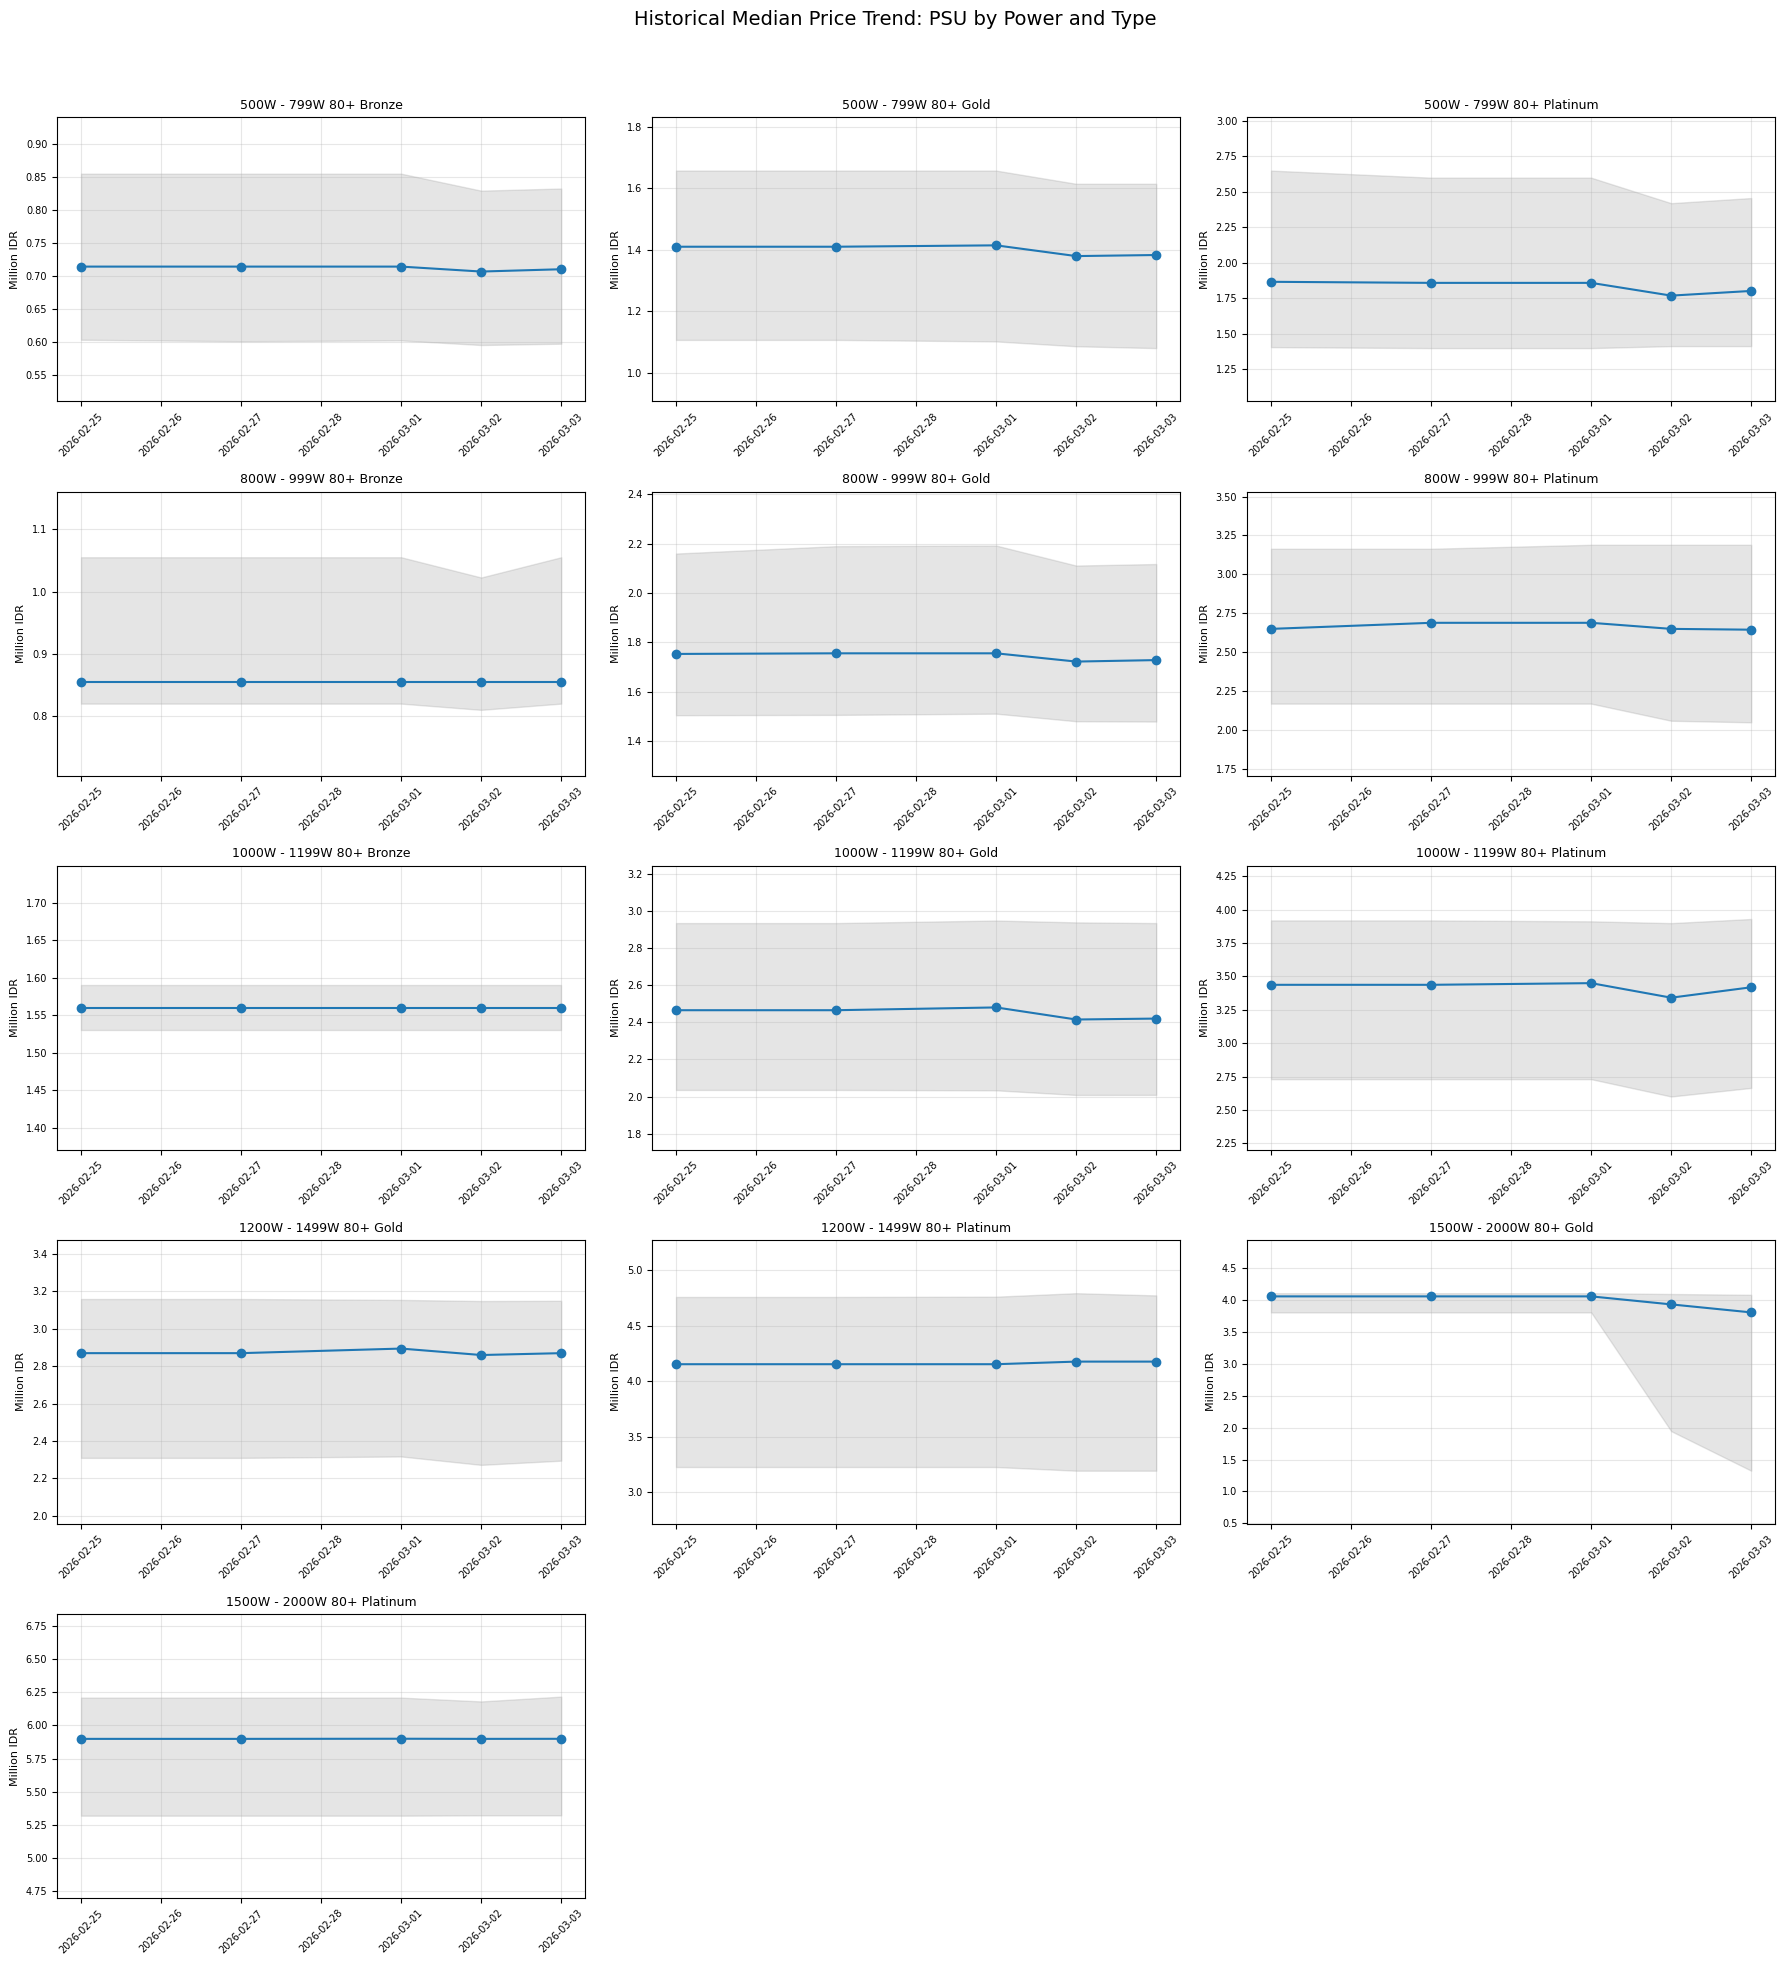

In [ ]:
# Historical trend: PSU by power and type
PSU_CATEGORIES = [
    '500W - 799W 80+ Bronze', '500W - 799W 80+ Gold', '500W - 799W 80+ Platinum',
    '800W - 999W 80+ Bronze', '800W - 999W 80+ Gold', '800W - 999W 80+ Platinum',
    '1000W - 1199W 80+ Bronze', '1000W - 1199W 80+ Gold', '1000W - 1199W 80+ Platinum',
    '1200W - 1499W 80+ Gold', '1200W - 1499W 80+ Platinum',
    '1500W - 2000W 80+ Gold', '1500W - 2000W 80+ Platinum',
]

psu_medians: dict[str, list[float | None]] = defaultdict(list)
psu_q1: dict[str, list[float | None]] = defaultdict(list)
psu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.PSU, [])
    prices_by_psu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        info = result_to_product_info(title, ProductCategory.PSU, int(x.price))
        if info is None or not isinstance(info.details, PSUInfo):
            continue
        try:
            power_range = info.details.power_range
        except ValueError:
            continue
        label = f'{power_range.value} 80+ {info.details.psu_type.value}'
        if label in PSU_CATEGORIES:
            prices_by_psu[label].append(info.price)
    for label in PSU_CATEGORIES:
        if label in prices_by_psu:
            prices = prices_by_psu[label]
            psu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                psu_q1[label].append(qs[0] / 1e6)
                psu_q3[label].append(qs[2] / 1e6)
            else:
                psu_q1[label].append(prices[0] / 1e6)
                psu_q3[label].append(prices[0] / 1e6)
        else:
            psu_medians[label].append(None)
            psu_q1[label].append(None)
            psu_q3[label].append(None)

plot_historical_trend(dates, psu_medians, psu_q1, psu_q3, PSU_CATEGORIES,
    'PSU by Power and Type', 'PSU Category', show_all=True)

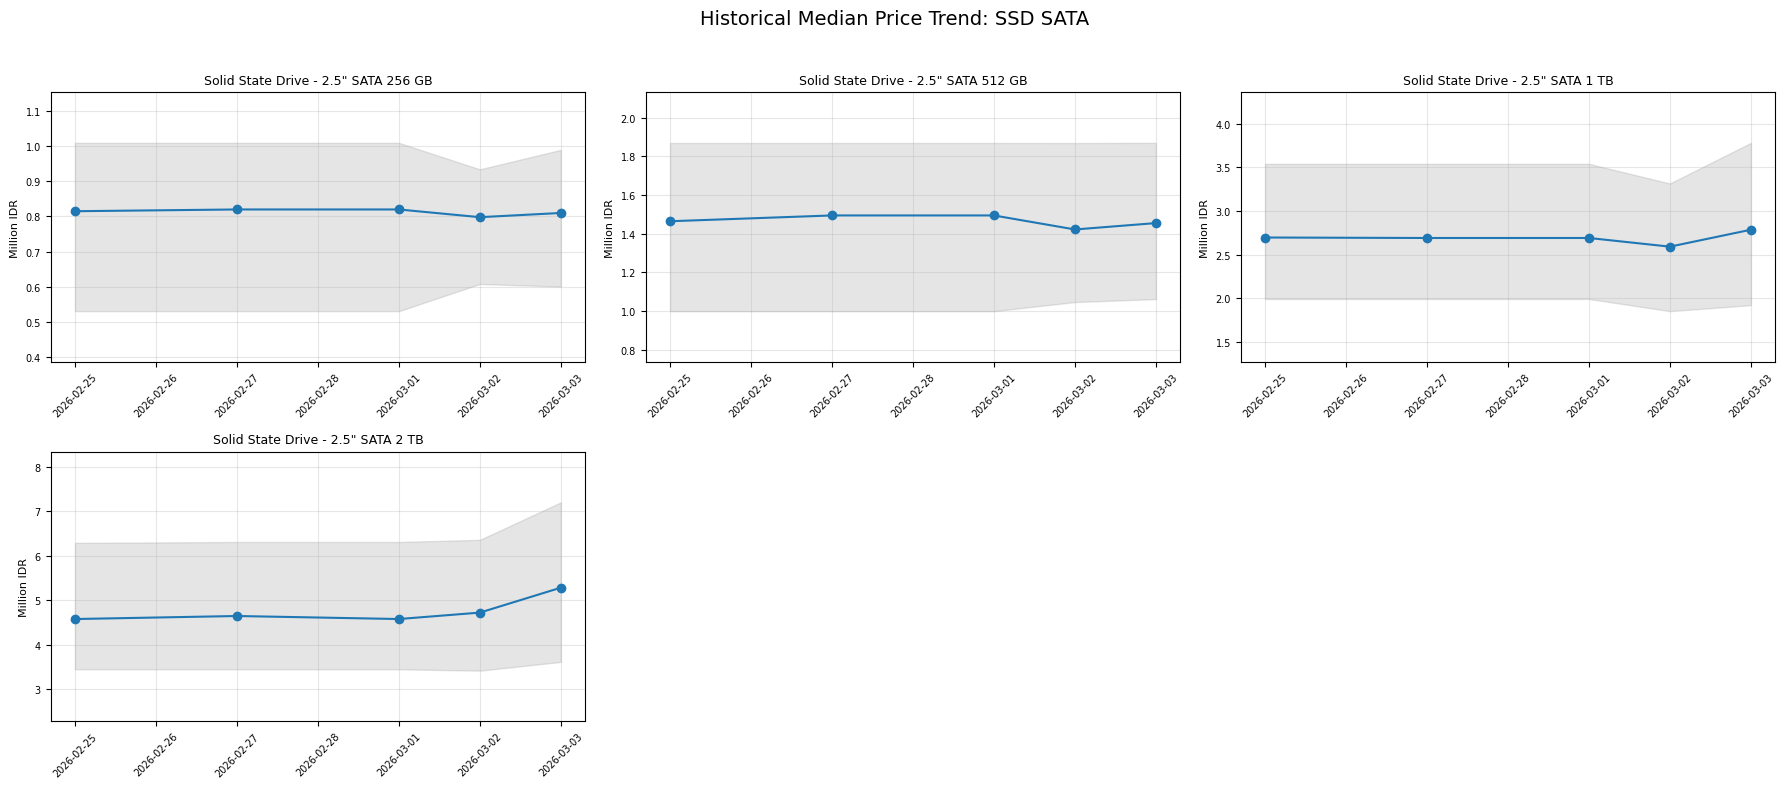

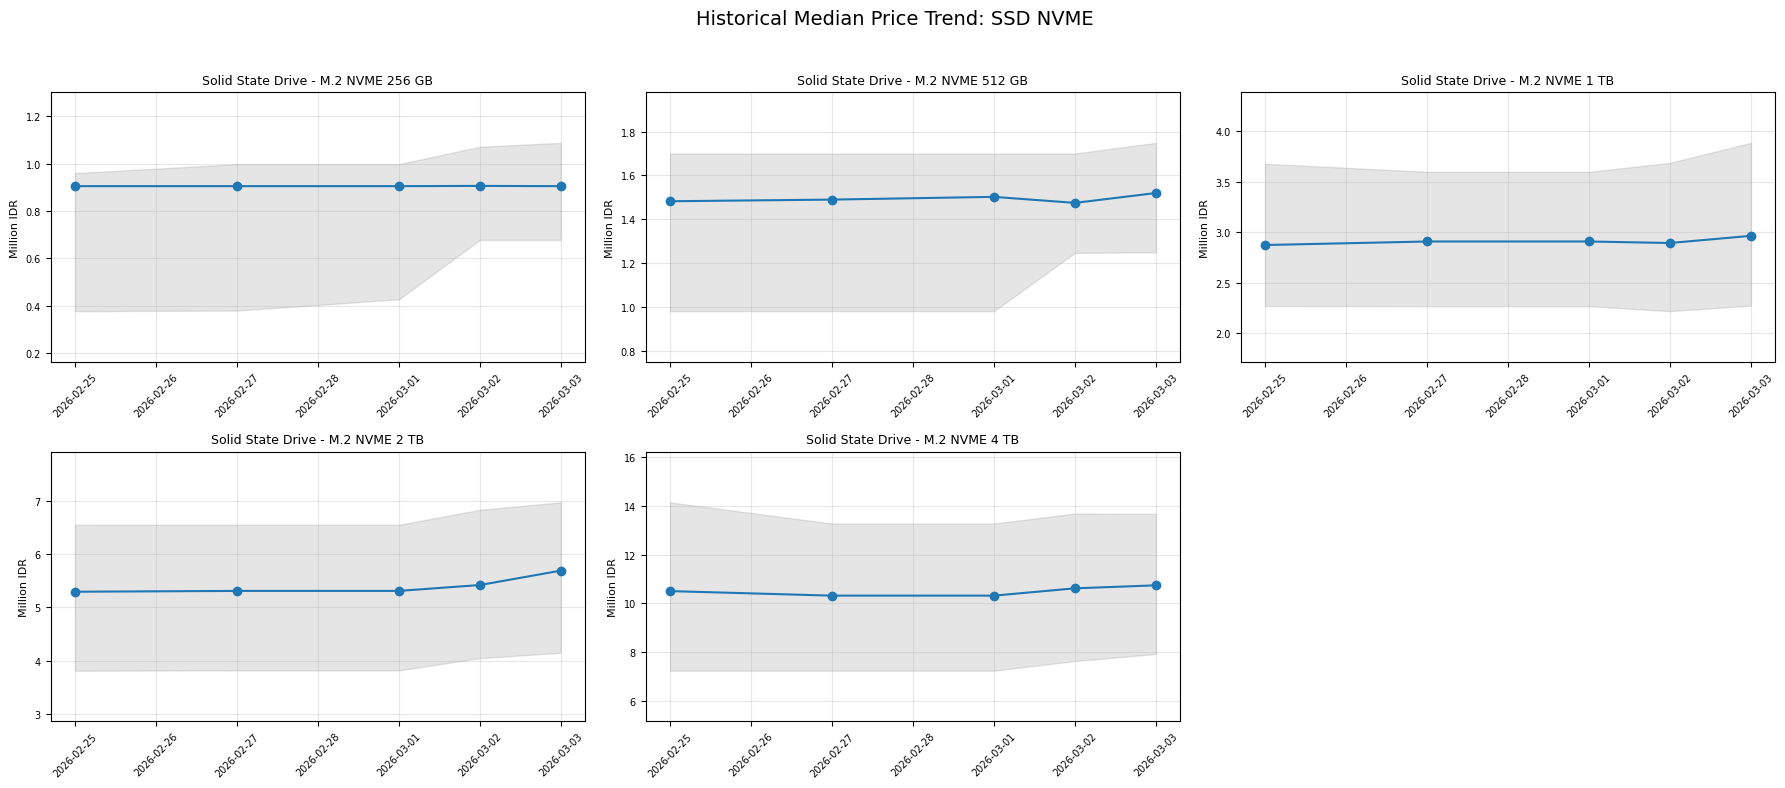

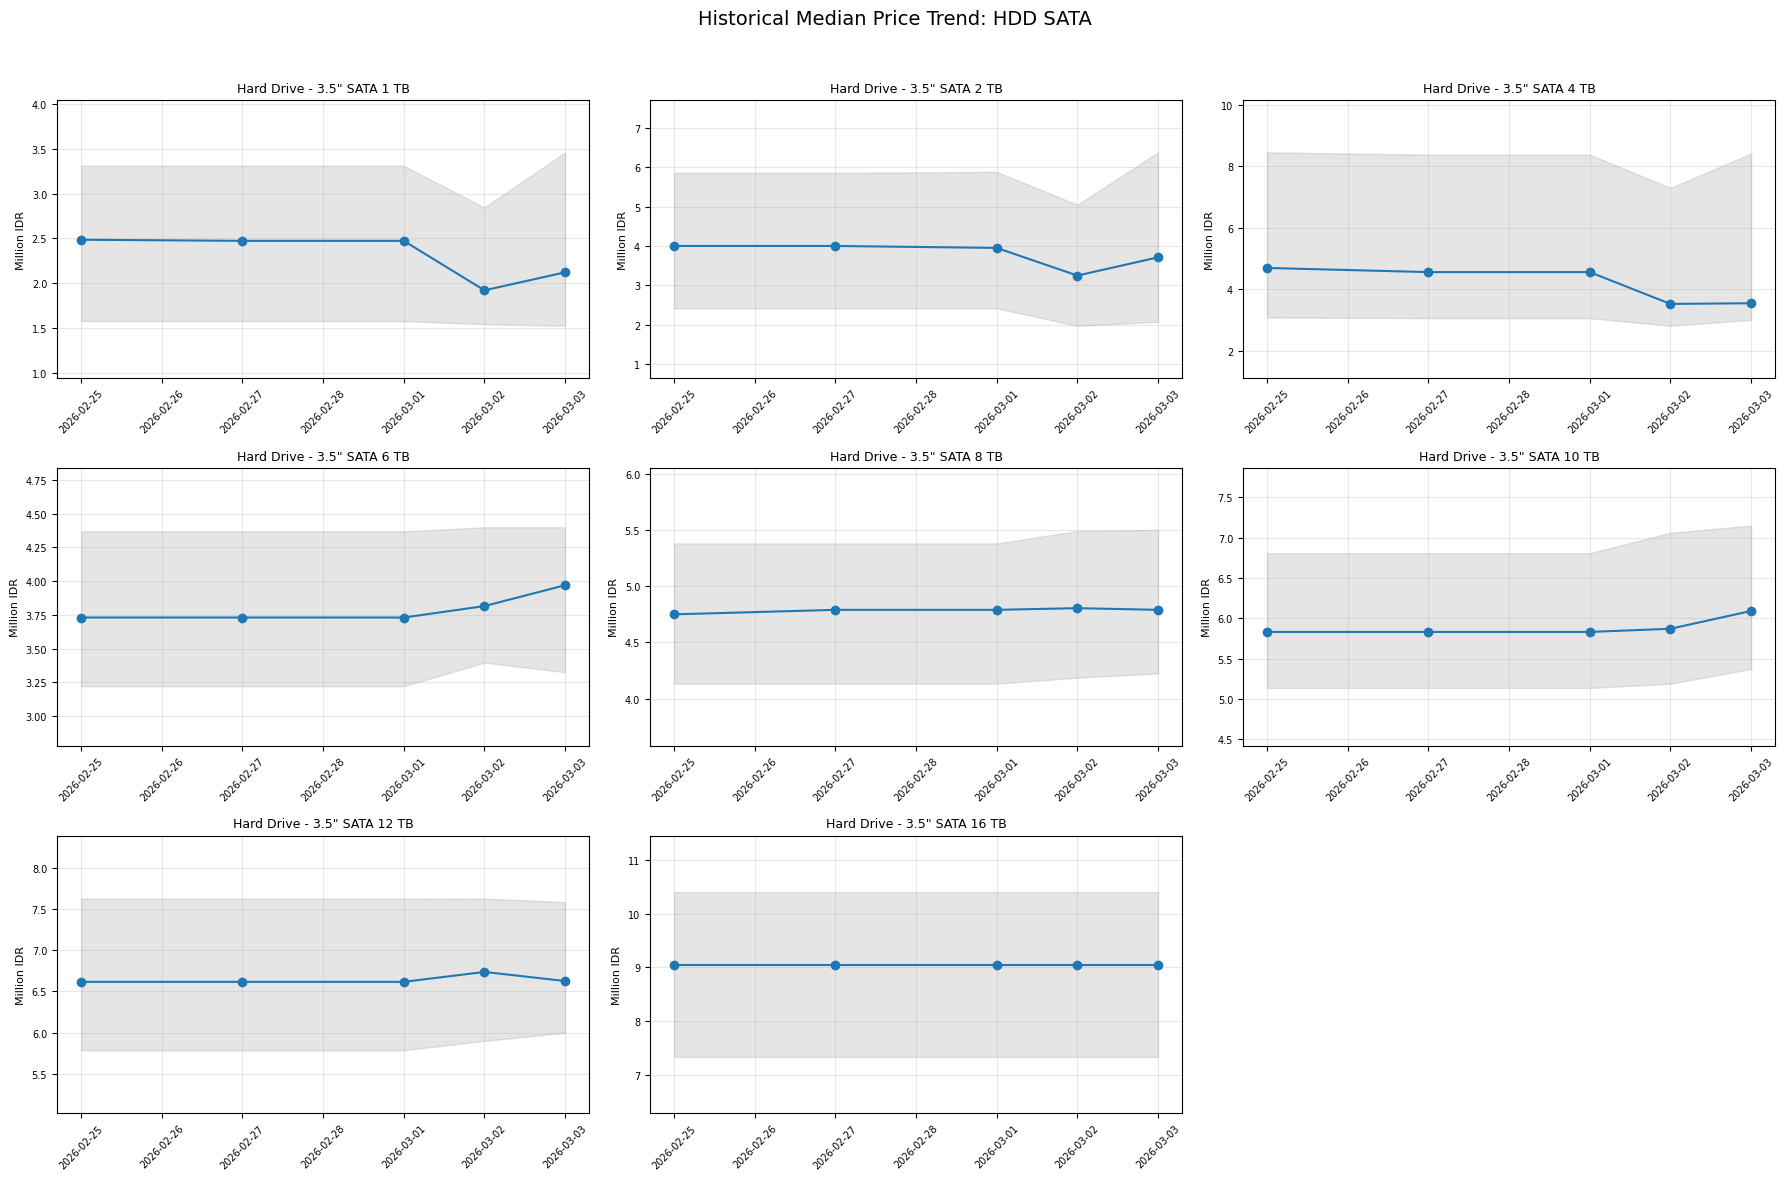

In [ ]:
# Historical trend: Disk — split into SSD SATA, SSD NVME, HDD SATA
def format_capacity(capacity_gb):
    if capacity_gb >= 1000:
        return f'{capacity_gb // 1000} TB'
    return f'{capacity_gb} GB'

DISK_TYPE_LABELS = {
    DiskType.SSD: 'Solid State Drive',
    DiskType.HDD: 'Hard Drive',
}

SSD_SATA_CATEGORIES = [
    'Solid State Drive - 2.5\" SATA 256 GB', 'Solid State Drive - 2.5\" SATA 512 GB',
    'Solid State Drive - 2.5\" SATA 1 TB', 'Solid State Drive - 2.5\" SATA 2 TB',
]

SSD_NVME_CATEGORIES = [
    'Solid State Drive - M.2 NVME 256 GB', 'Solid State Drive - M.2 NVME 512 GB',
    'Solid State Drive - M.2 NVME 1 TB', 'Solid State Drive - M.2 NVME 2 TB',
    'Solid State Drive - M.2 NVME 4 TB',
]

HDD_SATA_CATEGORIES = [
    'Hard Drive - 3.5\" SATA 1 TB', 'Hard Drive - 3.5\" SATA 2 TB',
    'Hard Drive - 3.5\" SATA 4 TB', 'Hard Drive - 3.5\" SATA 6 TB',
    'Hard Drive - 3.5\" SATA 8 TB', 'Hard Drive - 3.5\" SATA 10 TB',
    'Hard Drive - 3.5\" SATA 12 TB', 'Hard Drive - 3.5\" SATA 16 TB',
]

ALL_DISK_CATEGORIES = SSD_SATA_CATEGORIES + SSD_NVME_CATEGORIES + HDD_SATA_CATEGORIES

disk_medians: dict[str, list[float | None]] = defaultdict(list)
disk_q1: dict[str, list[float | None]] = defaultdict(list)
disk_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    ssd_prods = all_data_by_date[dt].get(ProductCategory.SSD, [])
    hdd_prods = all_data_by_date[dt].get(ProductCategory.HARDDISK, [])
    prices_by_disk: dict[str, list[int]] = defaultdict(list)
    for cat, prods in [(ProductCategory.SSD, ssd_prods), (ProductCategory.HARDDISK, hdd_prods)]:
        for x in prods:
            title = x.title + ' ' + (x.detail or '')
            info = result_to_product_info(title, cat, int(x.price))
            if info is None or not isinstance(info.details, DiskInfo):
                continue
            d = info.details
            type_label = DISK_TYPE_LABELS[d.disk_type]
            label = f'{type_label} - {d.form_factor.value} {format_capacity(d.capacity_gb)}'
            if label in ALL_DISK_CATEGORIES:
                prices_by_disk[label].append(info.price)
    for label in ALL_DISK_CATEGORIES:
        if label in prices_by_disk:
            prices = prices_by_disk[label]
            disk_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                disk_q1[label].append(qs[0] / 1e6)
                disk_q3[label].append(qs[2] / 1e6)
            else:
                disk_q1[label].append(prices[0] / 1e6)
                disk_q3[label].append(prices[0] / 1e6)
        else:
            disk_medians[label].append(None)
            disk_q1[label].append(None)
            disk_q3[label].append(None)

plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, SSD_SATA_CATEGORIES,
    'SSD SATA', 'Disk Category', show_all=True)
plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, SSD_NVME_CATEGORIES,
    'SSD NVME', 'Disk Category', show_all=True)
plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, HDD_SATA_CATEGORIES,
    'HDD SATA', 'Disk Category', show_all=True)

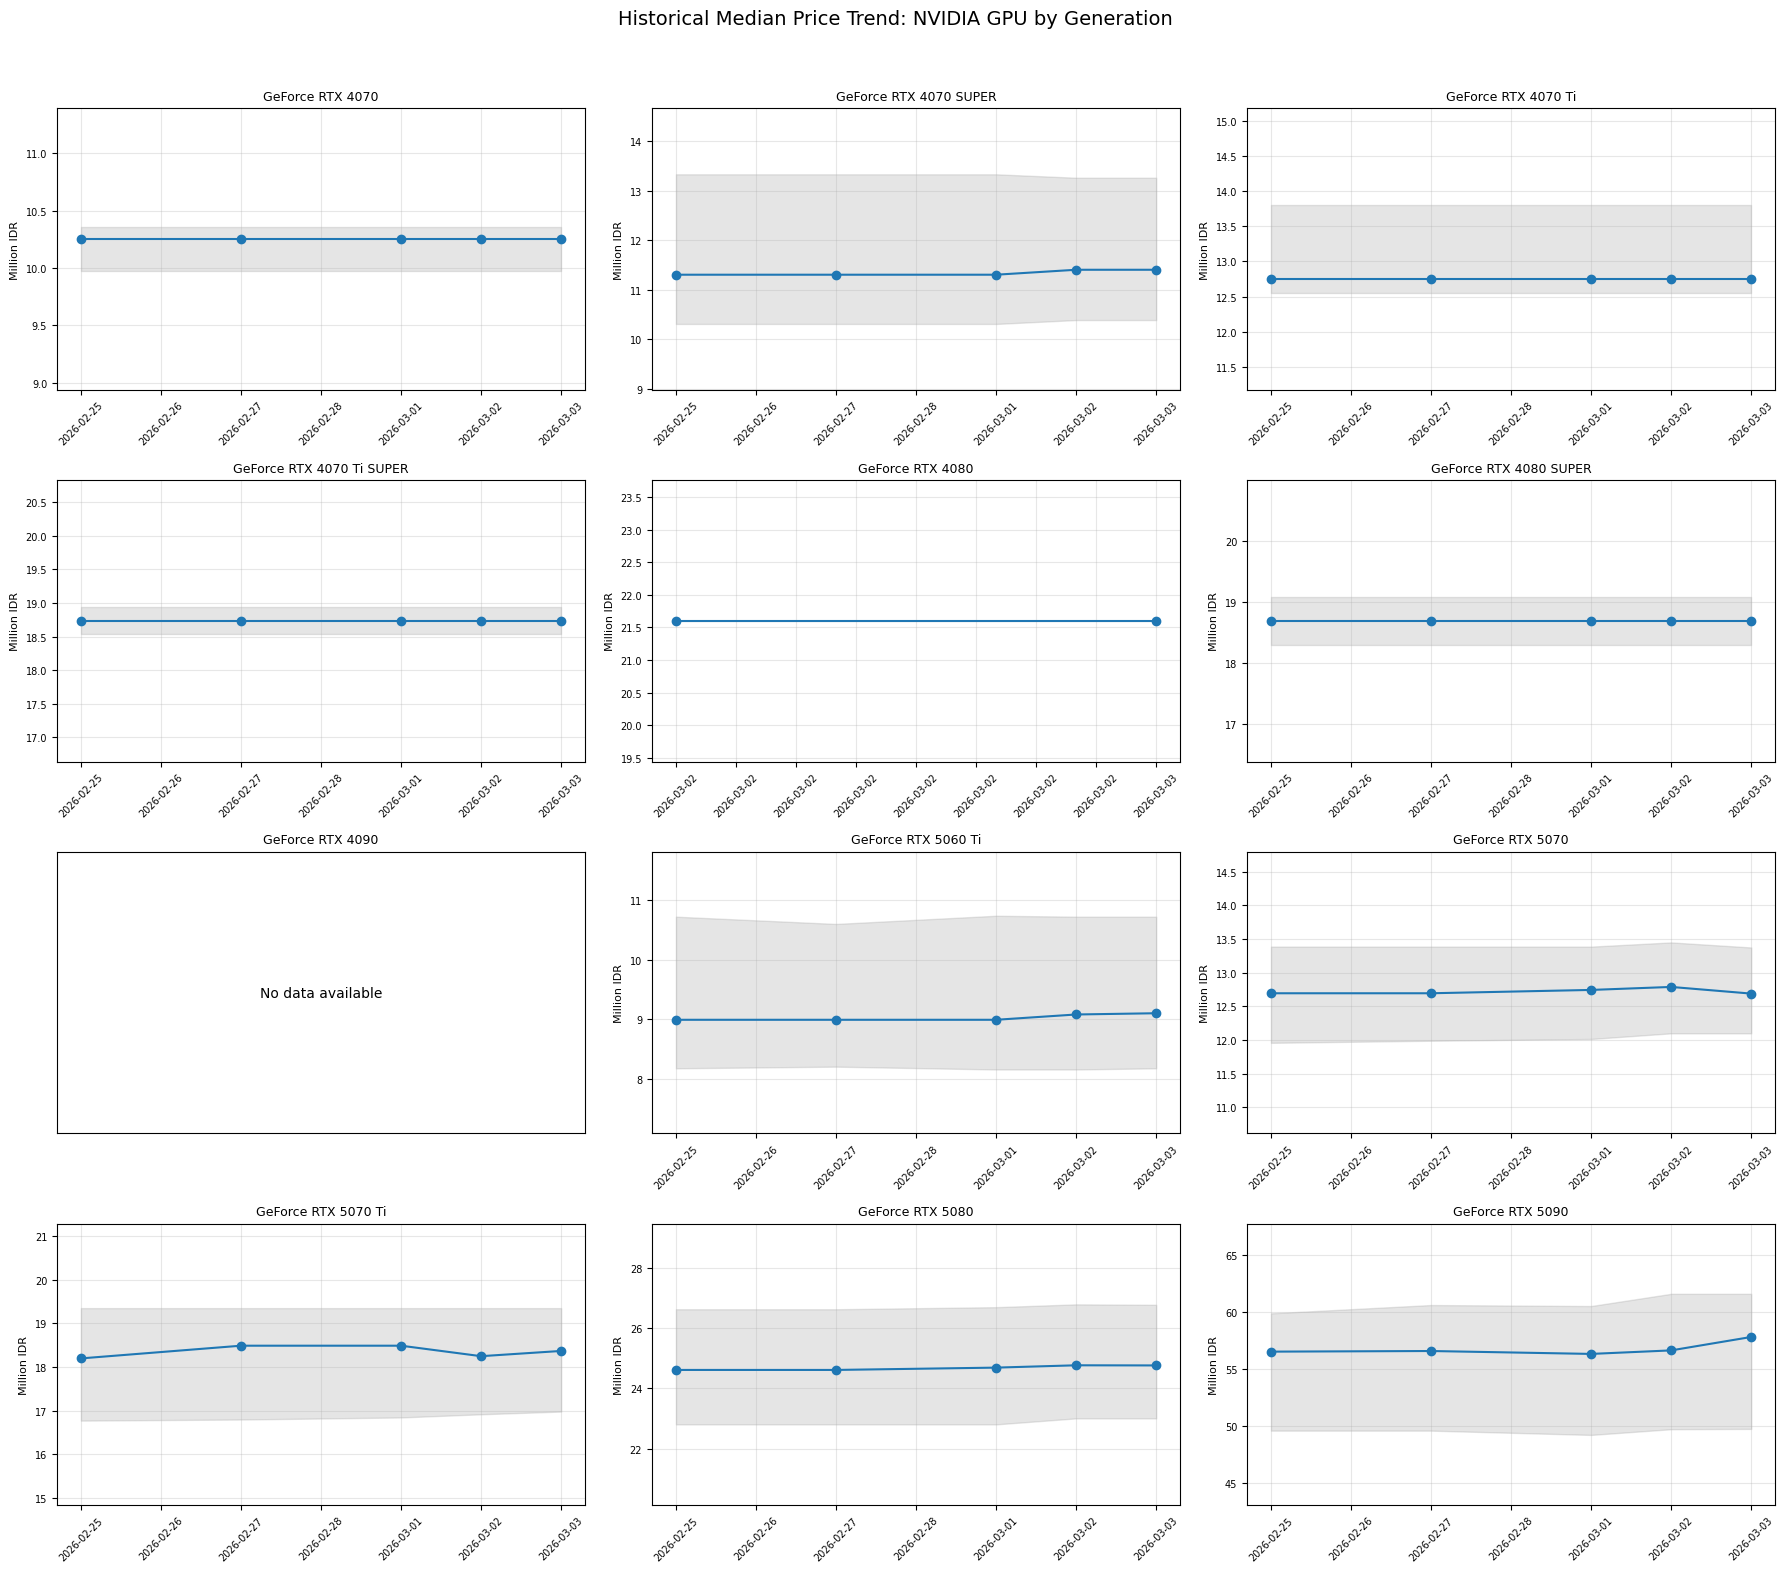

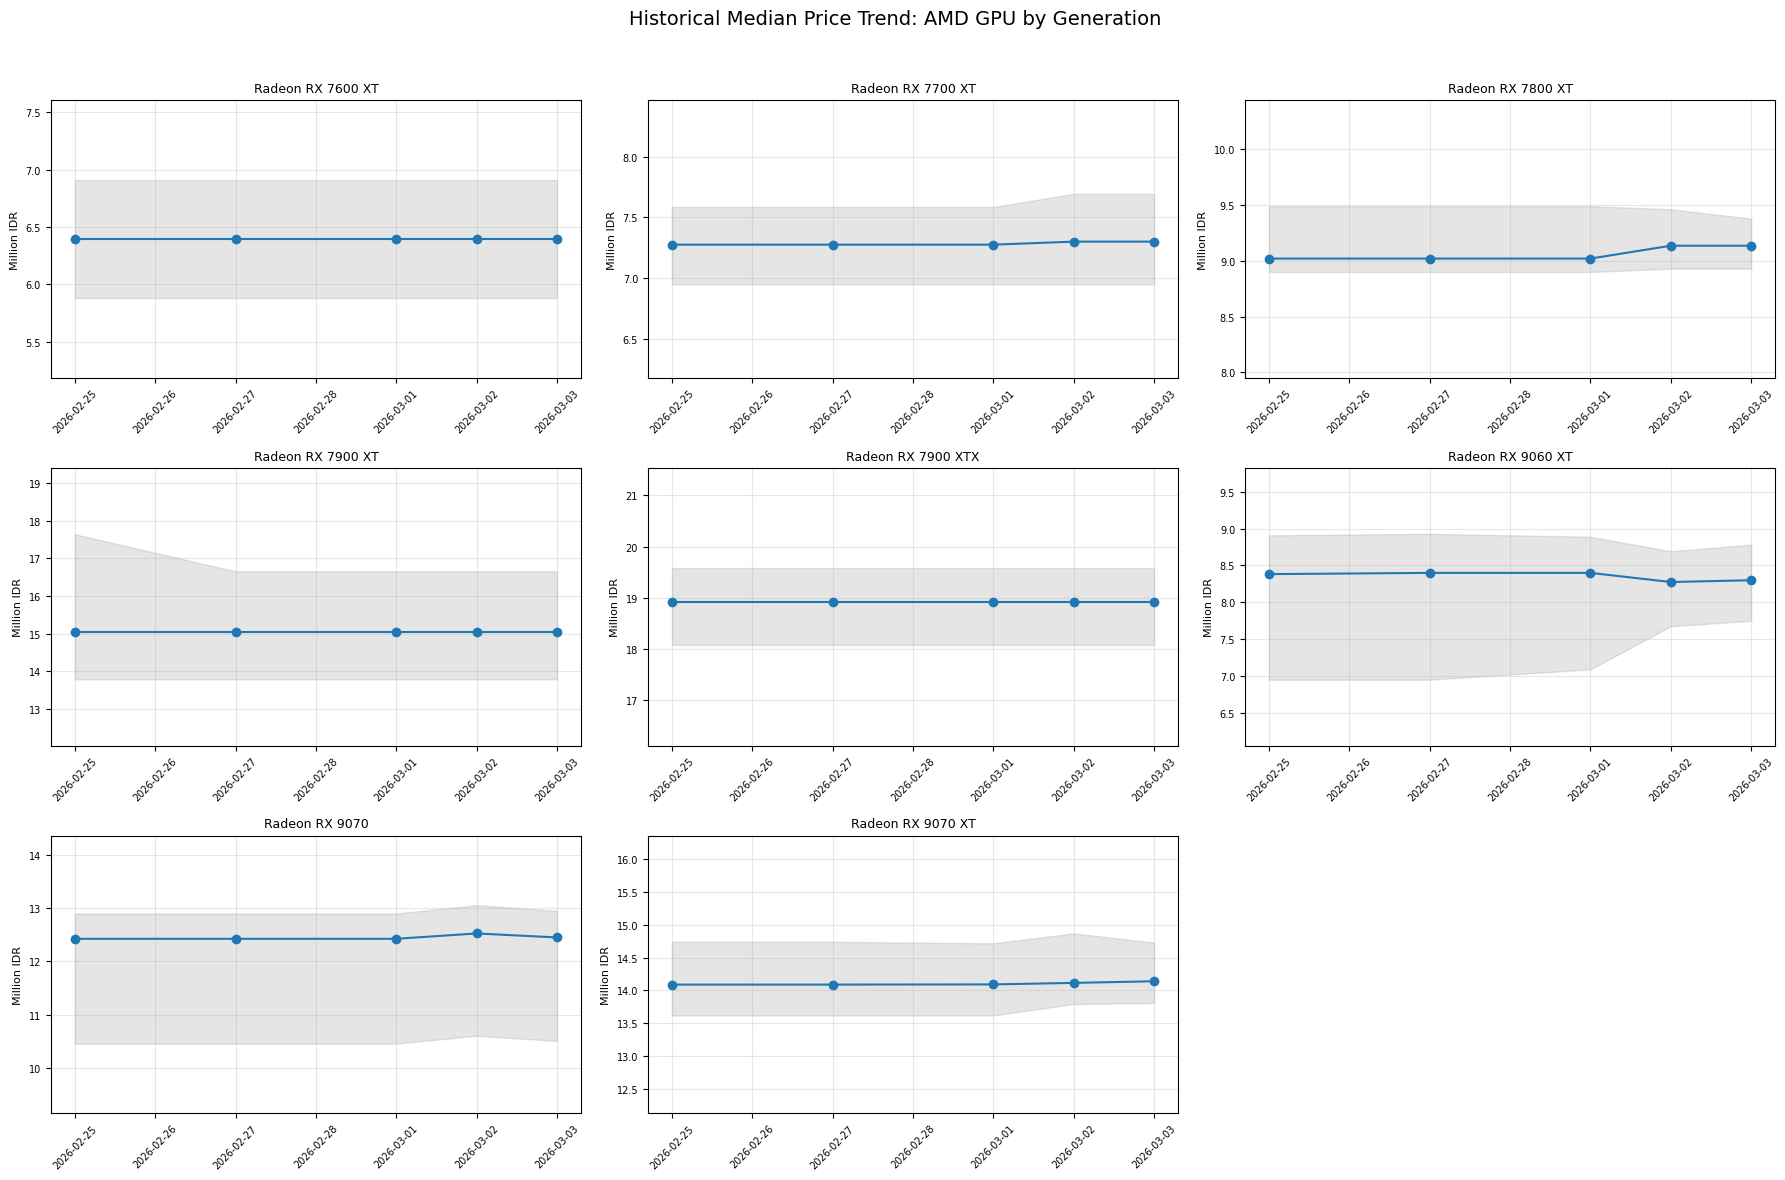

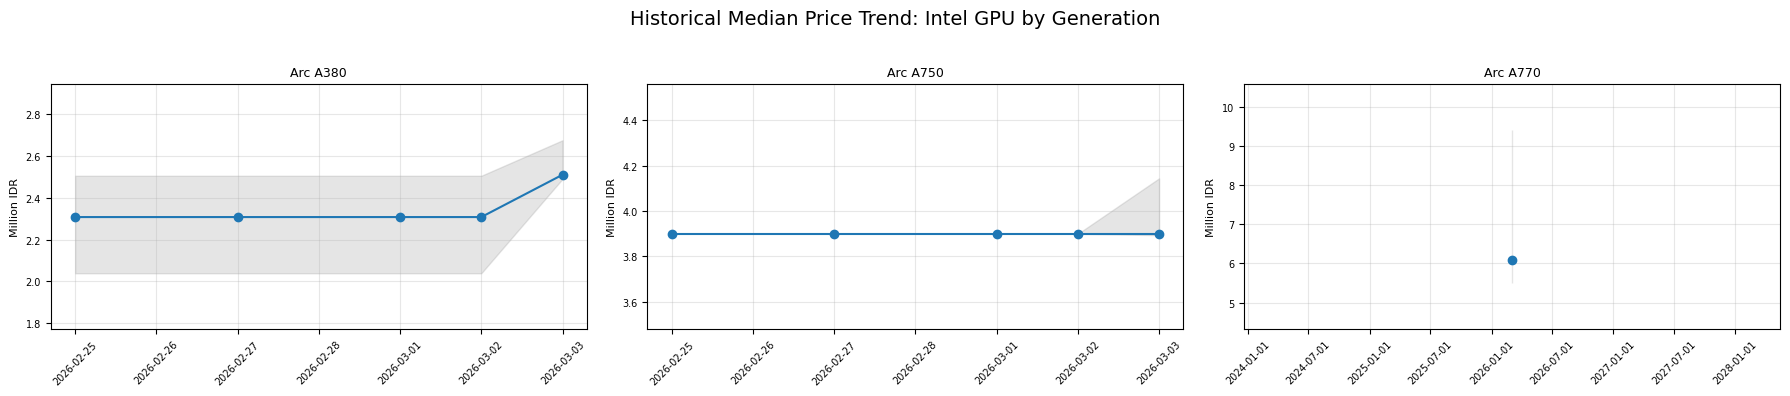

In [ ]:
# Historical trend: GPU — split by brand, each row = generation
GPU_MODELS = [
    'GeForce RTX 4070 Ti SUPER', 'GeForce RTX 4070 Ti', 'GeForce RTX 4070 SUPER',
    'GeForce RTX 4070', 'GeForce RTX 4080 SUPER', 'GeForce RTX 4080', 'GeForce RTX 4090',
    'GeForce RTX 5060 Ti', 'GeForce RTX 5070 Ti', 'GeForce RTX 5070',
    'GeForce RTX 5080', 'GeForce RTX 5090',
    'Radeon RX 7600 XT', 'Radeon RX 7700 XT', 'Radeon RX 7800 XT',
    'Radeon RX 7900 XTX', 'Radeon RX 7900 XT',
    'Radeon RX 9060 XT', 'Radeon RX 9070 XT', 'Radeon RX 9070',
    'Arc A770', 'Arc A750', 'Arc A380',
]

NVIDIA_GPU_ORDER = [
    'GeForce RTX 4070', 'GeForce RTX 4070 SUPER', 'GeForce RTX 4070 Ti',
    'GeForce RTX 4070 Ti SUPER', 'GeForce RTX 4080', 'GeForce RTX 4080 SUPER',
    'GeForce RTX 4090',
    'GeForce RTX 5060 Ti', 'GeForce RTX 5070',
    'GeForce RTX 5070 Ti', 'GeForce RTX 5080', 'GeForce RTX 5090',
]

AMD_GPU_ORDER = [
    'Radeon RX 7600 XT', 'Radeon RX 7700 XT', 'Radeon RX 7800 XT',
    'Radeon RX 7900 XT', 'Radeon RX 7900 XTX',
    'Radeon RX 9060 XT', 'Radeon RX 9070', 'Radeon RX 9070 XT',
]

INTEL_GPU_ORDER = [
    'Arc A380', 'Arc A750', 'Arc A770',
]

ALL_GPU_ORDER = NVIDIA_GPU_ORDER + AMD_GPU_ORDER + INTEL_GPU_ORDER

def get_gpu_category(title):
    title_lower = title.lower()
    for model in GPU_MODELS:
        if model.lower() in title_lower:
            return model
    return None

gpu_medians: dict[str, list[float | None]] = defaultdict(list)
gpu_q1: dict[str, list[float | None]] = defaultdict(list)
gpu_q3: dict[str, list[float | None]] = defaultdict(list)

for dt in dates:
    prods = all_data_by_date[dt].get(ProductCategory.VGA, [])
    prices_by_gpu: dict[str, list[int]] = defaultdict(list)
    for x in prods:
        title = x.title + ' ' + (x.detail or '')
        model = get_gpu_category(title)
        if model is None:
            continue
        prices_by_gpu[model].append(int(x.price))
    for label in ALL_GPU_ORDER:
        if label in prices_by_gpu:
            prices = prices_by_gpu[label]
            gpu_medians[label].append(median(prices) / 1e6)
            if len(prices) >= 2:
                qs = quantiles(prices, n=4)
                gpu_q1[label].append(qs[0] / 1e6)
                gpu_q3[label].append(qs[2] / 1e6)
            else:
                gpu_q1[label].append(prices[0] / 1e6)
                gpu_q3[label].append(prices[0] / 1e6)
        else:
            gpu_medians[label].append(None)
            gpu_q1[label].append(None)
            gpu_q3[label].append(None)

plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, NVIDIA_GPU_ORDER,
    'NVIDIA GPU by Generation', 'GPU Model', show_all=True)
plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, AMD_GPU_ORDER,
    'AMD GPU by Generation', 'GPU Model', show_all=True)
plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, INTEL_GPU_ORDER,
    'Intel GPU by Generation', 'GPU Model', show_all=True)

In [73]:
import base64
from io import BytesIO
from datetime import date as _date_cls, datetime

# Collect all historical figures
_collected_figs: list[tuple[str, plt.Figure]] = []

# RAM
plot_historical_trend(dates, ram_medians, ram_q1, ram_q3, ALL_RAM_LABELS,
    'RAM', 'RAM Type', show_all=True, collect_figs=_collected_figs)

# CPU
plot_historical_trend(dates, cpu_medians, cpu_q1, cpu_q3, AMD_CPU_CATEGORIES,
    'AMD CPU', 'CPU Category', show_all=True, collect_figs=_collected_figs)
plot_historical_trend(dates, cpu_medians, cpu_q1, cpu_q3, INTEL_CPU_CATEGORIES,
    'Intel CPU', 'CPU Category', show_all=True, max_cols=4, collect_figs=_collected_figs)

# PSU
plot_historical_trend(dates, psu_medians, psu_q1, psu_q3, PSU_CATEGORIES,
    'PSU', 'PSU Category', show_all=True, collect_figs=_collected_figs)

# Disk
plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, SSD_SATA_CATEGORIES,
    'SSD SATA', 'Disk Category', show_all=True, collect_figs=_collected_figs)
plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, SSD_NVME_CATEGORIES,
    'SSD NVME', 'Disk Category', show_all=True, collect_figs=_collected_figs)
plot_historical_trend(dates, disk_medians, disk_q1, disk_q3, HDD_SATA_CATEGORIES,
    'HDD SATA', 'Disk Category', show_all=True, collect_figs=_collected_figs)

# GPU
plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, NVIDIA_GPU_ORDER,
    'NVIDIA GPU', 'GPU Model', show_all=True, collect_figs=_collected_figs)
plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, AMD_GPU_ORDER,
    'AMD GPU', 'GPU Model', show_all=True, collect_figs=_collected_figs)
plot_historical_trend(dates, gpu_medians, gpu_q1, gpu_q3, INTEL_GPU_ORDER,
    'Intel GPU', 'GPU Model', show_all=True, collect_figs=_collected_figs)

# Build HTML
dt = datetime.now().isoformat(sep=" ", timespec="seconds")
html_parts = [
    '<!DOCTYPE html>',
    '<html><head><meta charset="utf-8">',
    f'<title>Hardware Prices - Historical Trends ({dt})</title>',
    '<style>body{font-family:sans-serif;max-width:1200px;margin:0 auto;padding:20px}',
    'h1{text-align:center}h2{margin-top:40px;border-bottom:1px solid #ccc;padding-bottom:8px}',
    'img{max-width:100%;height:auto;display:block;margin:10px auto}</style>',
    '</head><body>',
    f'<h1>Hardware Prices</h1>',
    f'<p style="text-align:center;color:#666">Generated on {dt}</p>',
    f'<p style="text-align:center;color:#666">Created by <a href="https://x.com/ro_rre">@ro_rre</a></p>',
]

for title, fig in _collected_figs:
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    html_parts.append(f'<h2>{title}</h2>')
    html_parts.append(f'<img src="data:image/png;base64,{img_b64}">')

html_parts.append('</body></html>')

output_path = Path('data') / f'historical_trends_{_date_cls.today().isoformat()}.html'
output_path.write_text('\n'.join(html_parts), encoding='utf-8')
print(f'Exported {len(_collected_figs)} graphs to {output_path}')

Exported 10 graphs to data/historical_trends_2026-03-03.html
